<a href="https://colab.research.google.com/github/Rupya2012/wallace53/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LibreLane Colab

This Google Colab notebook will:
* Install LibreLane and its dependencies
* Run a simple design, namely a serial-parallel multiplier, through the flow
  and targeting the [open source sky130 PDK](https://github.com/google/skywater-pdk/)
  by Google and Skywater.

In [1]:
# @title Setup Nix {display-mode: "form"}
# @markdown <img src="https://raw.githubusercontent.com/NixOS/nixos-artwork/51a27e4a011e95cb559e37d32c44cf89b50f5154/logo/nix-snowflake-colours.svg" width="32"/>
# @markdown
# @markdown Nix is a package manager with an emphasis on reproducible builds,
# @markdown and it is the primary method for installing LibreLane.
# @markdown
# @markdown This step installs the Nix package manager and enables the
# @markdown FOSSi Foundation Nix Cache.
# @markdown
# @markdown If you're not in a Colab, this just sets the environment variables.
# @markdown You will need to install Nix and enable flakes on your own following
# @markdown [this guide](https://librelane.readthedocs.io/en/stable/getting_started/common/nix_installation/index.html).
import os
from pathlib import Path
import subprocess
import sys
import shutil
import tempfile

os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"

if "google.colab" in sys.modules:
    if shutil.which("nix-env") is None:
        with tempfile.TemporaryDirectory() as d:
            d = Path(d)
            installer_path = d / "nix"
            !curl --proto '=https' --tlsv1.2 -sSf -L https://install.determinate.systems/nix > {installer_path}
            with subprocess.Popen(
                [
                    "bash",
                    installer_path,
                    "install",
                    "--prefer-upstream-nix",
                    "--no-confirm",
                    "--extra-conf",
                    "extra-substituters = https://nix-cache.fossi-foundation.org\nextra-trusted-public-keys = nix-cache.fossi-foundation.org:3+K59iFwXqKsL7BNu6Guy0v+uTlwsxYQxjspXzqLYQs=\n",
                ],
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                encoding="utf8",
            ) as p:
                for line in p.stdout:
                    print(line, end="")
else:
    if shutil.which("nix-env") is None:
        raise RuntimeError("Nix is not installed!")

os.environ["PATH"] = f"/nix/var/nix/profiles/default/bin/:{os.getenv('PATH')}"

info: downloading the Determinate Nix Installer
 INFO nix-installer v3.21.0
 INFO Step: Create directory `/nix`
 INFO Step: Provision Nix
 INFO Step: Create build users (UID 30001-30032) and group (GID 30000)
 INFO Step: Configure Nix
 INFO Step: Create directory `/etc/tmpfiles.d`
 INFO Step: Configure upstream Nix daemon service
 INFO Step: Cleanup
 INFO Running self test for shell sh
 INFO Running self test for shell bash
 WARN SelfTest([ShellFailed { shell: Sh, command: "\"sh\" \"-lc\" \"exec nix build --option substitute false --option post-build-hook \\'\\' --no-link --expr \\'derivation { name = \\\"self-test-sh-1780564694359\\\"; system = \\\"x86_64-linux\\\"; builder = \\\"/bin/sh\\\"; args = [\\\"-c\\\" \\\"echo hello > \\\\$out\\\"]; }\\'\"", output: Output { status: ExitStatus(unix_wait_status(256)), stdout: "", stderr: "error:\n       … while calling the 'derivationStrict' builtin\n         at «nix-internal»/derivation-internal.nix:37:12:\n           36|\n           37|   s

In [2]:
# @title Get LibreLane {display-mode: "form"}
# @markdown Click the ▷ button to download and install LibreLane.
# @markdown
# @markdown This will install LibreLane's tool dependencies using Nix,
# @markdown and LibreLane itself using PIP.
# @markdown
# @markdown Note that `python3-tk` may need to be installed using your OS's
# @markdown package manager.
import os
import yaml
import subprocess
import IPython

librelane_version = "latest"  # @param {key:"LibreLane Version", type:"string"}

if librelane_version == "latest":
    librelane_version = "main"

pdk_root = "~/.ciel"  # @param {key:"PDK Root", type:"string"}

pdk_root = os.path.expanduser(pdk_root)

pdk = "sky130"  # @param {key:"PDK (without the variant)", type:"string"}

librelane_ipynb_path = os.path.join(os.getcwd(), "librelane_ipynb")

display(IPython.display.HTML("<h3>Downloading LibreLane…</a>"))


TESTING_LOCALLY = False
!rm -rf {librelane_ipynb_path}
!mkdir -p {librelane_ipynb_path}
if TESTING_LOCALLY:
    !ln -s {os.getcwd()} {librelane_ipynb_path}
else:
    !curl -L "https://github.com/librelane/librelane/tarball/{librelane_version}" | tar -xzC {librelane_ipynb_path} --strip-components 1

try:
    import tkinter
except ImportError:
    if "google.colab" in sys.modules:
        !sudo apt-get install python-tk

try:
    import tkinter
except ImportError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to import the <code>tkinter</code> library for Python, which is required to load PDK configuration values. Make sure <code>python3-tk</code> or equivalent is installed on your system.</a>'
        )
    )
    raise e from None


display(IPython.display.HTML("<h3>Downloading LibreLane's dependencies…</a>"))
try:
    with subprocess.Popen(
        [
            "nix",
            "profile",
            "install",
            ".#colab-env",
        ],
        cwd=librelane_ipynb_path,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        encoding="utf8",
    ) as p:
        for line in p.stdout:
            print(line, end="")
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install binary dependencies using Nix…</h3>'
        )
    )

display(IPython.display.HTML("<h3>Downloading Python dependencies using PIP…</a>"))
try:
    subprocess.check_call(
        ["pip3", "install", "."],
        cwd=librelane_ipynb_path,
    )
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install Python dependencies using PIP…</h3>'
        )
    )
    raise e from None

display(IPython.display.HTML("<h3>Downloading PDK…</a>"))
import ciel
from ciel.source import StaticWebDataSource

with open(
    os.path.join(librelane_ipynb_path, "librelane", "pdk_hashes.yaml"), "r"
) as file:
    pdk_hashes = yaml.safe_load(file)

ciel.enable(
    ciel.get_ciel_home(pdk_root),
    pdk,
    pdk_hashes[pdk],
    data_source=StaticWebDataSource("https://fossi-foundation.github.io/ciel-releases"),
)

sys.path.insert(0, librelane_ipynb_path)
display(IPython.display.HTML("<h3>⭕️ Done.</a>"))

import logging

# Remove the stupid default colab logging handler
logging.getLogger().handlers.clear()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 8901k    0 8901k    0     0  9241k      0 --:--:-- --:--:-- --:--:-- 40.8M


unpacking 'github:fossi-foundation/nix-eda/8f990fb77529c09e540e453cd836af9930ec58db?narHash=sha256-nSKBMGP8/ZC7qB3Lzd%2BFwM8REqOxlh8wpYDf2hlK6Gg%3D' into the Git cache...
copying path '/nix/store/sizirny50f893gx0gbivbqyys4fxghnq-source' from 'https://cache.nixos.org'...
unpacking 'github:numtide/devshell/255a2b1725a20d060f566e4755dbf571bbbb5f76?narHash=sha256-460jc0%2BCZfyaO8%2Bw8JNtlClB2n4ui1RbHfPTLkpwhU8%3D' into the Git cache...
copying path '/nix/store/7fd6kzwyq6pcaigmq887p9wccl7v3dl6-source' from 'https://cache.nixos.org'...
this derivation will be built:
  /nix/store/jgd55f2c85x2qc6jbynqpawn9ky5vxml-librelane-colab-env.drv
these 318 paths will be fetched (818.5 MiB download, 4.8 GiB unpacked):
  /nix/store/6rkc8a7wg89fvpvdnq2nvjk46wya6jly-abseil-cpp-20240722.1
  /nix/store/7qfvcajvjs89fxqk4379zhbdmlmxjaxb-abseil-cpp-20250814.1
  /nix/store/fwfpzqrvzhpjp91rbnq64z07diyicbwh-acl-2.3.2
  /nix/store/gmpw5fapb46sm5fxirwsyl1zicx2mrax-alsa-lib-1.2.14
  /nix/store/7l478kjr588ic8l6l32qxr60

Version 8afc8346a57fe1ab7934ba5a6056ea8b43078e71 not found locally, attempting to download…

Output()

Output()

...

Output()

Output()

Output()

Output()

Version 8afc8346a57fe1ab7934ba5a6056ea8b43078e71 enabled for the sky130 PDK.

In [3]:
import librelane

print(librelane.__version__)

3.0.3


### Creating the design

Now that LibreLane is set up, we can write a Verilog file as follows:

In [4]:
%%writefile spm.v

module wallace16_n53(
    input  [15:0] a,
    input  [15:0] b,
    output  [31:0] sum
);
wire [31:0] row0;
wire [31:0] row1 ;
wire pp_0_0, pp_0_1, pp_0_2, pp_0_3, pp_0_4, pp_0_5, pp_0_6, pp_0_7;
wire pp_0_8, pp_0_9, pp_0_10, pp_0_11, pp_0_12, pp_0_13, pp_0_14, pp_0_15;
wire pp_1_0, pp_1_1, pp_1_2, pp_1_3, pp_1_4, pp_1_5, pp_1_6, pp_1_7;
wire pp_1_8, pp_1_9, pp_1_10, pp_1_11, pp_1_12, pp_1_13, pp_1_14, pp_1_15;
wire pp_2_0, pp_2_1, pp_2_2, pp_2_3, pp_2_4, pp_2_5, pp_2_6, pp_2_7;
wire pp_2_8, pp_2_9, pp_2_10, pp_2_11, pp_2_12, pp_2_13, pp_2_14, pp_2_15;
wire pp_3_0, pp_3_1, pp_3_2, pp_3_3, pp_3_4, pp_3_5, pp_3_6, pp_3_7;
wire pp_3_8, pp_3_9, pp_3_10, pp_3_11, pp_3_12, pp_3_13, pp_3_14, pp_3_15;
wire pp_4_0, pp_4_1, pp_4_2, pp_4_3, pp_4_4, pp_4_5, pp_4_6, pp_4_7;
wire pp_4_8, pp_4_9, pp_4_10, pp_4_11, pp_4_12, pp_4_13, pp_4_14, pp_4_15;
wire pp_5_0, pp_5_1, pp_5_2, pp_5_3, pp_5_4, pp_5_5, pp_5_6, pp_5_7;
wire pp_5_8, pp_5_9, pp_5_10, pp_5_11, pp_5_12, pp_5_13, pp_5_14, pp_5_15;
wire pp_6_0, pp_6_1, pp_6_2, pp_6_3, pp_6_4, pp_6_5, pp_6_6, pp_6_7;
wire pp_6_8, pp_6_9, pp_6_10, pp_6_11, pp_6_12, pp_6_13, pp_6_14, pp_6_15;
wire pp_7_0, pp_7_1, pp_7_2, pp_7_3, pp_7_4, pp_7_5, pp_7_6, pp_7_7;
wire pp_7_8, pp_7_9, pp_7_10, pp_7_11, pp_7_12, pp_7_13, pp_7_14, pp_7_15;
wire pp_8_0, pp_8_1, pp_8_2, pp_8_3, pp_8_4, pp_8_5, pp_8_6, pp_8_7;
wire pp_8_8, pp_8_9, pp_8_10, pp_8_11, pp_8_12, pp_8_13, pp_8_14, pp_8_15;
wire pp_9_0, pp_9_1, pp_9_2, pp_9_3, pp_9_4, pp_9_5, pp_9_6, pp_9_7;
wire pp_9_8, pp_9_9, pp_9_10, pp_9_11, pp_9_12, pp_9_13, pp_9_14, pp_9_15;
wire pp_10_0, pp_10_1, pp_10_2, pp_10_3, pp_10_4, pp_10_5, pp_10_6, pp_10_7;
wire pp_10_8, pp_10_9, pp_10_10, pp_10_11, pp_10_12, pp_10_13, pp_10_14, pp_10_15;
wire pp_11_0, pp_11_1, pp_11_2, pp_11_3, pp_11_4, pp_11_5, pp_11_6, pp_11_7;
wire pp_11_8, pp_11_9, pp_11_10, pp_11_11, pp_11_12, pp_11_13, pp_11_14, pp_11_15;
wire pp_12_0, pp_12_1, pp_12_2, pp_12_3, pp_12_4, pp_12_5, pp_12_6, pp_12_7;
wire pp_12_8, pp_12_9, pp_12_10, pp_12_11, pp_12_12, pp_12_13, pp_12_14, pp_12_15;
wire pp_13_0, pp_13_1, pp_13_2, pp_13_3, pp_13_4, pp_13_5, pp_13_6, pp_13_7;
wire pp_13_8, pp_13_9, pp_13_10, pp_13_11, pp_13_12, pp_13_13, pp_13_14, pp_13_15;
wire pp_14_0, pp_14_1, pp_14_2, pp_14_3, pp_14_4, pp_14_5, pp_14_6, pp_14_7;
wire pp_14_8, pp_14_9, pp_14_10, pp_14_11, pp_14_12, pp_14_13, pp_14_14, pp_14_15;
wire pp_15_0, pp_15_1, pp_15_2, pp_15_3, pp_15_4, pp_15_5, pp_15_6, pp_15_7;
wire pp_15_8, pp_15_9, pp_15_10, pp_15_11, pp_15_12, pp_15_13, pp_15_14, pp_15_15;
wire s0_c10_53_s0_0, s0_c10_53_s0_1, s0_c10_53_s1_0, s0_c10_53_s1_1, s0_c10_53_s2_0, s0_c10_53_s2_1, s0_c11_53_s0_0, s0_c11_53_s0_1;
wire s0_c11_53_s1_0, s0_c11_53_s1_1, s0_c11_53_s2_0, s0_c11_53_s2_1, s0_c12_53_s0_0, s0_c12_53_s0_1, s0_c12_53_s1_0, s0_c12_53_s1_1;
wire s0_c12_53_s2_0, s0_c12_53_s2_1, s0_c13_53_s0_0, s0_c13_53_s0_1, s0_c13_53_s1_0, s0_c13_53_s1_1, s0_c13_53_s2_0, s0_c13_53_s2_1;
wire s0_c14_53_s0_0, s0_c14_53_s0_1, s0_c14_53_s0_2, s0_c14_53_s1_0, s0_c14_53_s1_1, s0_c14_53_s1_2, s0_c14_53_s2_0, s0_c14_53_s2_1;
wire s0_c14_53_s2_2, s0_c15_53_s0_0, s0_c15_53_s0_1, s0_c15_53_s0_2, s0_c15_53_s1_0, s0_c15_53_s1_1, s0_c15_53_s1_2, s0_c15_53_s2_0;
wire s0_c15_53_s2_1, s0_c15_53_s2_2, s0_c16_53_s0_0, s0_c16_53_s0_1, s0_c16_53_s0_2, s0_c16_53_s1_0, s0_c16_53_s1_1, s0_c16_53_s1_2;
wire s0_c16_53_s2_0, s0_c16_53_s2_1, s0_c16_53_s2_2, s0_c17_32_c_0, s0_c17_32_s_0, s0_c17_53_s0_0, s0_c17_53_s0_1, s0_c17_53_s1_0;
wire s0_c17_53_s1_1, s0_c17_53_s2_0, s0_c17_53_s2_1, s0_c18_53_s0_0, s0_c18_53_s0_1, s0_c18_53_s1_0, s0_c18_53_s1_1, s0_c18_53_s2_0;
wire s0_c18_53_s2_1, s0_c19_53_s0_0, s0_c19_53_s0_1, s0_c19_53_s1_0, s0_c19_53_s1_1, s0_c19_53_s2_0, s0_c19_53_s2_1, s0_c20_53_s0_0;
wire s0_c20_53_s0_1, s0_c20_53_s1_0, s0_c20_53_s1_1, s0_c20_53_s2_0, s0_c20_53_s2_1, s0_c21_53_s0_0, s0_c21_53_s0_1, s0_c21_53_s1_0;
wire s0_c21_53_s1_1, s0_c21_53_s2_0, s0_c21_53_s2_1, s0_c22_53_s0_0, s0_c22_53_s1_0, s0_c22_53_s2_0, s0_c23_53_s0_0, s0_c23_53_s1_0;
wire s0_c23_53_s2_0, s0_c24_53_s0_0, s0_c24_53_s1_0, s0_c24_53_s2_0, s0_c25_53_s0_0, s0_c25_53_s1_0, s0_c25_53_s2_0, s0_c26_53_s0_0;
wire s0_c26_53_s1_0, s0_c26_53_s2_0, s0_c4_53_s0_0, s0_c4_53_s1_0, s0_c4_53_s2_0, s0_c5_53_s0_0, s0_c5_53_s1_0, s0_c5_53_s2_0;
wire s0_c6_53_s0_0, s0_c6_53_s1_0, s0_c6_53_s2_0, s0_c7_53_s0_0, s0_c7_53_s1_0, s0_c7_53_s2_0, s0_c8_53_s0_0, s0_c8_53_s1_0;
wire s0_c8_53_s2_0, s0_c9_53_s0_0, s0_c9_53_s0_1, s0_c9_53_s1_0, s0_c9_53_s1_1, s0_c9_53_s2_0, s0_c9_53_s2_1, s1_c10_53_s0_0;
wire s1_c10_53_s1_0, s1_c10_53_s2_0, s1_c11_53_s0_0, s1_c11_53_s1_0, s1_c11_53_s2_0, s1_c12_53_s0_0, s1_c12_53_s1_0, s1_c12_53_s2_0;
wire s1_c13_53_s0_0, s1_c13_53_s0_1, s1_c13_53_s1_0, s1_c13_53_s1_1, s1_c13_53_s2_0, s1_c13_53_s2_1, s1_c14_53_s0_0, s1_c14_53_s1_0;
wire s1_c14_53_s2_0, s1_c15_32_c_0, s1_c15_32_s_0, s1_c15_53_s0_0, s1_c15_53_s1_0, s1_c15_53_s2_0, s1_c16_32_c_0, s1_c16_32_s_0;
wire s1_c16_53_s0_0, s1_c16_53_s1_0, s1_c16_53_s2_0, s1_c17_53_s0_0, s1_c17_53_s0_1, s1_c17_53_s1_0, s1_c17_53_s1_1, s1_c17_53_s2_0;
wire s1_c17_53_s2_1, s1_c18_53_s0_0, s1_c18_53_s0_1, s1_c18_53_s1_0, s1_c18_53_s1_1, s1_c18_53_s2_0, s1_c18_53_s2_1, s1_c19_32_c_0;
wire s1_c19_32_s_0, s1_c19_53_s0_0, s1_c19_53_s1_0, s1_c19_53_s2_0, s1_c20_53_s0_0, s1_c20_53_s1_0, s1_c20_53_s2_0, s1_c21_53_s0_0;
wire s1_c21_53_s1_0, s1_c21_53_s2_0, s1_c22_53_s0_0, s1_c22_53_s1_0, s1_c22_53_s2_0, s1_c23_53_s0_0, s1_c23_53_s1_0, s1_c23_53_s2_0;
wire s1_c24_53_s0_0, s1_c24_53_s1_0, s1_c24_53_s2_0, s1_c27_53_s0_0, s1_c27_53_s1_0, s1_c27_53_s2_0, s1_c6_53_s0_0, s1_c6_53_s1_0;
wire s1_c6_53_s2_0, s1_c7_53_s0_0, s1_c7_53_s1_0, s1_c7_53_s2_0, s1_c8_53_s0_0, s1_c8_53_s1_0, s1_c8_53_s2_0, s2_c11_53_s0_0;
wire s2_c11_53_s1_0, s2_c11_53_s2_0, s2_c12_53_s0_0, s2_c12_53_s1_0, s2_c12_53_s2_0, s2_c13_32_c_0, s2_c13_32_s_0, s2_c14_53_s0_0;
wire s2_c14_53_s1_0, s2_c14_53_s2_0, s2_c15_53_s0_0, s2_c15_53_s1_0, s2_c15_53_s2_0, s2_c16_53_s0_0, s2_c16_53_s1_0, s2_c16_53_s2_0;
wire s2_c17_53_s0_0, s2_c17_53_s1_0, s2_c17_53_s2_0, s2_c18_53_s0_0, s2_c18_53_s1_0, s2_c18_53_s2_0, s2_c19_53_s0_0, s2_c19_53_s1_0;
wire s2_c19_53_s2_0, s2_c20_53_s0_0, s2_c20_53_s1_0, s2_c20_53_s2_0, s2_c21_32_c_0, s2_c21_32_s_0, s2_c22_53_s0_0, s2_c22_53_s1_0;
wire s2_c22_53_s2_0, s2_c23_53_s0_0, s2_c23_53_s1_0, s2_c23_53_s2_0, s2_c25_53_s0_0, s2_c25_53_s1_0, s2_c25_53_s2_0, s2_c28_53_s0_0;
wire s2_c28_53_s1_0, s2_c28_53_s2_0, s2_c8_53_s0_0, s2_c8_53_s1_0, s2_c8_53_s2_0, s2_c9_53_s0_0, s2_c9_53_s1_0, s2_c9_53_s2_0;
wire s3_c10_53_s0_0, s3_c10_53_s1_0, s3_c10_53_s2_0, s3_c12_32_c_0, s3_c12_32_s_0, s3_c13_32_c_0, s3_c13_32_s_0, s3_c14_32_c_0;
wire s3_c14_32_s_0, s3_c15_32_c_0, s3_c15_32_s_0, s3_c16_32_c_0, s3_c16_32_s_0, s3_c17_32_c_0, s3_c17_32_s_0, s3_c18_32_c_0;
wire s3_c18_32_s_0, s3_c19_32_c_0, s3_c19_32_s_0, s3_c20_53_s0_0, s3_c20_53_s1_0, s3_c20_53_s2_0, s3_c21_32_c_0, s3_c21_32_s_0;
wire s3_c22_53_s0_0, s3_c22_53_s1_0, s3_c22_53_s2_0, s3_c24_53_s0_0, s3_c24_53_s1_0, s3_c24_53_s2_0, s3_c25_32_c_0, s3_c25_32_s_0;
wire s3_c26_53_s0_0, s3_c26_53_s1_0, s3_c26_53_s2_0, s3_c27_32_c_0, s3_c27_32_s_0, s3_c29_32_c_0, s3_c29_32_s_0, s3_c3_32_c_0;
wire s3_c3_32_s_0, s4_c11_32_c_0, s4_c11_32_s_0, s4_c12_32_c_0, s4_c12_32_s_0, s4_c13_32_c_0, s4_c13_32_s_0, s4_c14_32_c_0;
wire s4_c14_32_s_0, s4_c15_22_c_0, s4_c15_22_s_0, s4_c16_32_c_0, s4_c16_32_s_0, s4_c17_22_c_0, s4_c17_22_s_0, s4_c18_32_c_0;
wire s4_c18_32_s_0, s4_c19_32_c_0, s4_c19_32_s_0, s4_c20_22_c_0, s4_c20_22_s_0, s4_c21_32_c_0, s4_c21_32_s_0, s4_c22_32_c_0;
wire s4_c22_32_s_0, s4_c23_32_c_0, s4_c23_32_s_0, s4_c24_22_c_0, s4_c24_22_s_0, s4_c25_22_c_0, s4_c25_22_s_0, s4_c26_32_c_0;
wire s4_c26_32_s_0, s4_c27_22_c_0, s4_c27_22_s_0, s4_c28_32_c_0, s4_c28_32_s_0, s4_c29_22_c_0, s4_c29_22_s_0, s4_c2_32_c_0;
wire s4_c2_32_s_0, s4_c30_32_c_0, s4_c30_32_s_0, s4_c3_22_c_0, s4_c3_22_s_0, s4_c4_22_c_0, s4_c4_22_s_0, s4_c5_32_c_0;
wire s4_c5_32_s_0, s4_c7_32_c_0, s4_c7_32_s_0, s4_c9_32_c_0, s4_c9_32_s_0;

assign pp_0_0 = a[0] & b[0];
assign pp_0_1 = a[0] & b[1];
assign pp_0_2 = a[0] & b[2];
assign pp_0_3 = a[0] & b[3];
assign pp_0_4 = a[0] & b[4];
assign pp_0_5 = a[0] & b[5];
assign pp_0_6 = a[0] & b[6];
assign pp_0_7 = a[0] & b[7];
assign pp_0_8 = a[0] & b[8];
assign pp_0_9 = a[0] & b[9];
assign pp_0_10 = a[0] & b[10];
assign pp_0_11 = a[0] & b[11];
assign pp_0_12 = a[0] & b[12];
assign pp_0_13 = a[0] & b[13];
assign pp_0_14 = a[0] & b[14];
assign pp_0_15 = a[0] & b[15];
assign pp_1_0 = a[1] & b[0];
assign pp_1_1 = a[1] & b[1];
assign pp_1_2 = a[1] & b[2];
assign pp_1_3 = a[1] & b[3];
assign pp_1_4 = a[1] & b[4];
assign pp_1_5 = a[1] & b[5];
assign pp_1_6 = a[1] & b[6];
assign pp_1_7 = a[1] & b[7];
assign pp_1_8 = a[1] & b[8];
assign pp_1_9 = a[1] & b[9];
assign pp_1_10 = a[1] & b[10];
assign pp_1_11 = a[1] & b[11];
assign pp_1_12 = a[1] & b[12];
assign pp_1_13 = a[1] & b[13];
assign pp_1_14 = a[1] & b[14];
assign pp_1_15 = a[1] & b[15];
assign pp_2_0 = a[2] & b[0];
assign pp_2_1 = a[2] & b[1];
assign pp_2_2 = a[2] & b[2];
assign pp_2_3 = a[2] & b[3];
assign pp_2_4 = a[2] & b[4];
assign pp_2_5 = a[2] & b[5];
assign pp_2_6 = a[2] & b[6];
assign pp_2_7 = a[2] & b[7];
assign pp_2_8 = a[2] & b[8];
assign pp_2_9 = a[2] & b[9];
assign pp_2_10 = a[2] & b[10];
assign pp_2_11 = a[2] & b[11];
assign pp_2_12 = a[2] & b[12];
assign pp_2_13 = a[2] & b[13];
assign pp_2_14 = a[2] & b[14];
assign pp_2_15 = a[2] & b[15];
assign pp_3_0 = a[3] & b[0];
assign pp_3_1 = a[3] & b[1];
assign pp_3_2 = a[3] & b[2];
assign pp_3_3 = a[3] & b[3];
assign pp_3_4 = a[3] & b[4];
assign pp_3_5 = a[3] & b[5];
assign pp_3_6 = a[3] & b[6];
assign pp_3_7 = a[3] & b[7];
assign pp_3_8 = a[3] & b[8];
assign pp_3_9 = a[3] & b[9];
assign pp_3_10 = a[3] & b[10];
assign pp_3_11 = a[3] & b[11];
assign pp_3_12 = a[3] & b[12];
assign pp_3_13 = a[3] & b[13];
assign pp_3_14 = a[3] & b[14];
assign pp_3_15 = a[3] & b[15];
assign pp_4_0 = a[4] & b[0];
assign pp_4_1 = a[4] & b[1];
assign pp_4_2 = a[4] & b[2];
assign pp_4_3 = a[4] & b[3];
assign pp_4_4 = a[4] & b[4];
assign pp_4_5 = a[4] & b[5];
assign pp_4_6 = a[4] & b[6];
assign pp_4_7 = a[4] & b[7];
assign pp_4_8 = a[4] & b[8];
assign pp_4_9 = a[4] & b[9];
assign pp_4_10 = a[4] & b[10];
assign pp_4_11 = a[4] & b[11];
assign pp_4_12 = a[4] & b[12];
assign pp_4_13 = a[4] & b[13];
assign pp_4_14 = a[4] & b[14];
assign pp_4_15 = a[4] & b[15];
assign pp_5_0 = a[5] & b[0];
assign pp_5_1 = a[5] & b[1];
assign pp_5_2 = a[5] & b[2];
assign pp_5_3 = a[5] & b[3];
assign pp_5_4 = a[5] & b[4];
assign pp_5_5 = a[5] & b[5];
assign pp_5_6 = a[5] & b[6];
assign pp_5_7 = a[5] & b[7];
assign pp_5_8 = a[5] & b[8];
assign pp_5_9 = a[5] & b[9];
assign pp_5_10 = a[5] & b[10];
assign pp_5_11 = a[5] & b[11];
assign pp_5_12 = a[5] & b[12];
assign pp_5_13 = a[5] & b[13];
assign pp_5_14 = a[5] & b[14];
assign pp_5_15 = a[5] & b[15];
assign pp_6_0 = a[6] & b[0];
assign pp_6_1 = a[6] & b[1];
assign pp_6_2 = a[6] & b[2];
assign pp_6_3 = a[6] & b[3];
assign pp_6_4 = a[6] & b[4];
assign pp_6_5 = a[6] & b[5];
assign pp_6_6 = a[6] & b[6];
assign pp_6_7 = a[6] & b[7];
assign pp_6_8 = a[6] & b[8];
assign pp_6_9 = a[6] & b[9];
assign pp_6_10 = a[6] & b[10];
assign pp_6_11 = a[6] & b[11];
assign pp_6_12 = a[6] & b[12];
assign pp_6_13 = a[6] & b[13];
assign pp_6_14 = a[6] & b[14];
assign pp_6_15 = a[6] & b[15];
assign pp_7_0 = a[7] & b[0];
assign pp_7_1 = a[7] & b[1];
assign pp_7_2 = a[7] & b[2];
assign pp_7_3 = a[7] & b[3];
assign pp_7_4 = a[7] & b[4];
assign pp_7_5 = a[7] & b[5];
assign pp_7_6 = a[7] & b[6];
assign pp_7_7 = a[7] & b[7];
assign pp_7_8 = a[7] & b[8];
assign pp_7_9 = a[7] & b[9];
assign pp_7_10 = a[7] & b[10];
assign pp_7_11 = a[7] & b[11];
assign pp_7_12 = a[7] & b[12];
assign pp_7_13 = a[7] & b[13];
assign pp_7_14 = a[7] & b[14];
assign pp_7_15 = a[7] & b[15];
assign pp_8_0 = a[8] & b[0];
assign pp_8_1 = a[8] & b[1];
assign pp_8_2 = a[8] & b[2];
assign pp_8_3 = a[8] & b[3];
assign pp_8_4 = a[8] & b[4];
assign pp_8_5 = a[8] & b[5];
assign pp_8_6 = a[8] & b[6];
assign pp_8_7 = a[8] & b[7];
assign pp_8_8 = a[8] & b[8];
assign pp_8_9 = a[8] & b[9];
assign pp_8_10 = a[8] & b[10];
assign pp_8_11 = a[8] & b[11];
assign pp_8_12 = a[8] & b[12];
assign pp_8_13 = a[8] & b[13];
assign pp_8_14 = a[8] & b[14];
assign pp_8_15 = a[8] & b[15];
assign pp_9_0 = a[9] & b[0];
assign pp_9_1 = a[9] & b[1];
assign pp_9_2 = a[9] & b[2];
assign pp_9_3 = a[9] & b[3];
assign pp_9_4 = a[9] & b[4];
assign pp_9_5 = a[9] & b[5];
assign pp_9_6 = a[9] & b[6];
assign pp_9_7 = a[9] & b[7];
assign pp_9_8 = a[9] & b[8];
assign pp_9_9 = a[9] & b[9];
assign pp_9_10 = a[9] & b[10];
assign pp_9_11 = a[9] & b[11];
assign pp_9_12 = a[9] & b[12];
assign pp_9_13 = a[9] & b[13];
assign pp_9_14 = a[9] & b[14];
assign pp_9_15 = a[9] & b[15];
assign pp_10_0 = a[10] & b[0];
assign pp_10_1 = a[10] & b[1];
assign pp_10_2 = a[10] & b[2];
assign pp_10_3 = a[10] & b[3];
assign pp_10_4 = a[10] & b[4];
assign pp_10_5 = a[10] & b[5];
assign pp_10_6 = a[10] & b[6];
assign pp_10_7 = a[10] & b[7];
assign pp_10_8 = a[10] & b[8];
assign pp_10_9 = a[10] & b[9];
assign pp_10_10 = a[10] & b[10];
assign pp_10_11 = a[10] & b[11];
assign pp_10_12 = a[10] & b[12];
assign pp_10_13 = a[10] & b[13];
assign pp_10_14 = a[10] & b[14];
assign pp_10_15 = a[10] & b[15];
assign pp_11_0 = a[11] & b[0];
assign pp_11_1 = a[11] & b[1];
assign pp_11_2 = a[11] & b[2];
assign pp_11_3 = a[11] & b[3];
assign pp_11_4 = a[11] & b[4];
assign pp_11_5 = a[11] & b[5];
assign pp_11_6 = a[11] & b[6];
assign pp_11_7 = a[11] & b[7];
assign pp_11_8 = a[11] & b[8];
assign pp_11_9 = a[11] & b[9];
assign pp_11_10 = a[11] & b[10];
assign pp_11_11 = a[11] & b[11];
assign pp_11_12 = a[11] & b[12];
assign pp_11_13 = a[11] & b[13];
assign pp_11_14 = a[11] & b[14];
assign pp_11_15 = a[11] & b[15];
assign pp_12_0 = a[12] & b[0];
assign pp_12_1 = a[12] & b[1];
assign pp_12_2 = a[12] & b[2];
assign pp_12_3 = a[12] & b[3];
assign pp_12_4 = a[12] & b[4];
assign pp_12_5 = a[12] & b[5];
assign pp_12_6 = a[12] & b[6];
assign pp_12_7 = a[12] & b[7];
assign pp_12_8 = a[12] & b[8];
assign pp_12_9 = a[12] & b[9];
assign pp_12_10 = a[12] & b[10];
assign pp_12_11 = a[12] & b[11];
assign pp_12_12 = a[12] & b[12];
assign pp_12_13 = a[12] & b[13];
assign pp_12_14 = a[12] & b[14];
assign pp_12_15 = a[12] & b[15];
assign pp_13_0 = a[13] & b[0];
assign pp_13_1 = a[13] & b[1];
assign pp_13_2 = a[13] & b[2];
assign pp_13_3 = a[13] & b[3];
assign pp_13_4 = a[13] & b[4];
assign pp_13_5 = a[13] & b[5];
assign pp_13_6 = a[13] & b[6];
assign pp_13_7 = a[13] & b[7];
assign pp_13_8 = a[13] & b[8];
assign pp_13_9 = a[13] & b[9];
assign pp_13_10 = a[13] & b[10];
assign pp_13_11 = a[13] & b[11];
assign pp_13_12 = a[13] & b[12];
assign pp_13_13 = a[13] & b[13];
assign pp_13_14 = a[13] & b[14];
assign pp_13_15 = a[13] & b[15];
assign pp_14_0 = a[14] & b[0];
assign pp_14_1 = a[14] & b[1];
assign pp_14_2 = a[14] & b[2];
assign pp_14_3 = a[14] & b[3];
assign pp_14_4 = a[14] & b[4];
assign pp_14_5 = a[14] & b[5];
assign pp_14_6 = a[14] & b[6];
assign pp_14_7 = a[14] & b[7];
assign pp_14_8 = a[14] & b[8];
assign pp_14_9 = a[14] & b[9];
assign pp_14_10 = a[14] & b[10];
assign pp_14_11 = a[14] & b[11];
assign pp_14_12 = a[14] & b[12];
assign pp_14_13 = a[14] & b[13];
assign pp_14_14 = a[14] & b[14];
assign pp_14_15 = a[14] & b[15];
assign pp_15_0 = a[15] & b[0];
assign pp_15_1 = a[15] & b[1];
assign pp_15_2 = a[15] & b[2];
assign pp_15_3 = a[15] & b[3];
assign pp_15_4 = a[15] & b[4];
assign pp_15_5 = a[15] & b[5];
assign pp_15_6 = a[15] & b[6];
assign pp_15_7 = a[15] & b[7];
assign pp_15_8 = a[15] & b[8];
assign pp_15_9 = a[15] & b[9];
assign pp_15_10 = a[15] & b[10];
assign pp_15_11 = a[15] & b[11];
assign pp_15_12 = a[15] & b[12];
assign pp_15_13 = a[15] & b[13];
assign pp_15_14 = a[15] & b[14];
assign pp_15_15 = a[15] & b[15];

comp53 u_0 (.a(pp_0_4), .b(pp_1_3), .c(pp_2_2), .d(pp_3_1), .e(pp_4_0), .s0(s0_c4_53_s0_0), .s1(s0_c4_53_s1_0), .s2(s0_c4_53_s2_0));
comp53 u_1 (.a(pp_0_5), .b(pp_1_4), .c(pp_2_3), .d(pp_3_2), .e(pp_4_1), .s0(s0_c5_53_s0_0), .s1(s0_c5_53_s1_0), .s2(s0_c5_53_s2_0));
comp53 u_2 (.a(pp_0_6), .b(pp_1_5), .c(pp_2_4), .d(pp_3_3), .e(pp_4_2), .s0(s0_c6_53_s0_0), .s1(s0_c6_53_s1_0), .s2(s0_c6_53_s2_0));
comp53 u_3 (.a(pp_0_7), .b(pp_1_6), .c(pp_2_5), .d(pp_3_4), .e(pp_4_3), .s0(s0_c7_53_s0_0), .s1(s0_c7_53_s1_0), .s2(s0_c7_53_s2_0));
comp53 u_4 (.a(pp_0_8), .b(pp_1_7), .c(pp_2_6), .d(pp_3_5), .e(pp_4_4), .s0(s0_c8_53_s0_0), .s1(s0_c8_53_s1_0), .s2(s0_c8_53_s2_0));
comp53 u_5 (.a(pp_0_9), .b(pp_1_8), .c(pp_2_7), .d(pp_3_6), .e(pp_4_5), .s0(s0_c9_53_s0_0), .s1(s0_c9_53_s1_0), .s2(s0_c9_53_s2_0));
comp53 u_6 (.a(pp_5_4), .b(pp_6_3), .c(pp_7_2), .d(pp_8_1), .e(pp_9_0), .s0(s0_c9_53_s0_1), .s1(s0_c9_53_s1_1), .s2(s0_c9_53_s2_1));
comp53 u_7 (.a(pp_0_10), .b(pp_1_9), .c(pp_2_8), .d(pp_3_7), .e(pp_4_6), .s0(s0_c10_53_s0_0), .s1(s0_c10_53_s1_0), .s2(s0_c10_53_s2_0));
comp53 u_8 (.a(pp_5_5), .b(pp_6_4), .c(pp_7_3), .d(pp_8_2), .e(pp_9_1), .s0(s0_c10_53_s0_1), .s1(s0_c10_53_s1_1), .s2(s0_c10_53_s2_1));
comp53 u_9 (.a(pp_0_11), .b(pp_1_10), .c(pp_2_9), .d(pp_3_8), .e(pp_4_7), .s0(s0_c11_53_s0_0), .s1(s0_c11_53_s1_0), .s2(s0_c11_53_s2_0));
comp53 u_10 (.a(pp_5_6), .b(pp_6_5), .c(pp_7_4), .d(pp_8_3), .e(pp_9_2), .s0(s0_c11_53_s0_1), .s1(s0_c11_53_s1_1), .s2(s0_c11_53_s2_1));
comp53 u_11 (.a(pp_0_12), .b(pp_1_11), .c(pp_2_10), .d(pp_3_9), .e(pp_4_8), .s0(s0_c12_53_s0_0), .s1(s0_c12_53_s1_0), .s2(s0_c12_53_s2_0));
comp53 u_12 (.a(pp_5_7), .b(pp_6_6), .c(pp_7_5), .d(pp_8_4), .e(pp_9_3), .s0(s0_c12_53_s0_1), .s1(s0_c12_53_s1_1), .s2(s0_c12_53_s2_1));
comp53 u_13 (.a(pp_0_13), .b(pp_1_12), .c(pp_2_11), .d(pp_3_10), .e(pp_4_9), .s0(s0_c13_53_s0_0), .s1(s0_c13_53_s1_0), .s2(s0_c13_53_s2_0));
comp53 u_14 (.a(pp_5_8), .b(pp_6_7), .c(pp_7_6), .d(pp_8_5), .e(pp_9_4), .s0(s0_c13_53_s0_1), .s1(s0_c13_53_s1_1), .s2(s0_c13_53_s2_1));
comp53 u_15 (.a(pp_0_14), .b(pp_1_13), .c(pp_2_12), .d(pp_3_11), .e(pp_4_10), .s0(s0_c14_53_s0_0), .s1(s0_c14_53_s1_0), .s2(s0_c14_53_s2_0));
comp53 u_16 (.a(pp_5_9), .b(pp_6_8), .c(pp_7_7), .d(pp_8_6), .e(pp_9_5), .s0(s0_c14_53_s0_1), .s1(s0_c14_53_s1_1), .s2(s0_c14_53_s2_1));
comp53 u_17 (.a(pp_10_4), .b(pp_11_3), .c(pp_12_2), .d(pp_13_1), .e(pp_14_0), .s0(s0_c14_53_s0_2), .s1(s0_c14_53_s1_2), .s2(s0_c14_53_s2_2));
comp53 u_18 (.a(pp_0_15), .b(pp_1_14), .c(pp_2_13), .d(pp_3_12), .e(pp_4_11), .s0(s0_c15_53_s0_0), .s1(s0_c15_53_s1_0), .s2(s0_c15_53_s2_0));
comp53 u_19 (.a(pp_5_10), .b(pp_6_9), .c(pp_7_8), .d(pp_8_7), .e(pp_9_6), .s0(s0_c15_53_s0_1), .s1(s0_c15_53_s1_1), .s2(s0_c15_53_s2_1));
comp53 u_20 (.a(pp_10_5), .b(pp_11_4), .c(pp_12_3), .d(pp_13_2), .e(pp_14_1), .s0(s0_c15_53_s0_2), .s1(s0_c15_53_s1_2), .s2(s0_c15_53_s2_2));
comp53 u_21 (.a(pp_1_15), .b(pp_2_14), .c(pp_3_13), .d(pp_4_12), .e(pp_5_11), .s0(s0_c16_53_s0_0), .s1(s0_c16_53_s1_0), .s2(s0_c16_53_s2_0));
comp53 u_22 (.a(pp_6_10), .b(pp_7_9), .c(pp_8_8), .d(pp_9_7), .e(pp_10_6), .s0(s0_c16_53_s0_1), .s1(s0_c16_53_s1_1), .s2(s0_c16_53_s2_1));
comp53 u_23 (.a(pp_11_5), .b(pp_12_4), .c(pp_13_3), .d(pp_14_2), .e(pp_15_1), .s0(s0_c16_53_s0_2), .s1(s0_c16_53_s1_2), .s2(s0_c16_53_s2_2));
comp32 u_24 (.a(pp_2_15), .b(pp_3_14), .c(pp_4_13), .sum(s0_c17_32_s_0), .carry(s0_c17_32_c_0));
comp53 u_25 (.a(pp_5_12), .b(pp_6_11), .c(pp_7_10), .d(pp_8_9), .e(pp_9_8), .s0(s0_c17_53_s0_0), .s1(s0_c17_53_s1_0), .s2(s0_c17_53_s2_0));
comp53 u_26 (.a(pp_10_7), .b(pp_11_6), .c(pp_12_5), .d(pp_13_4), .e(pp_14_3), .s0(s0_c17_53_s0_1), .s1(s0_c17_53_s1_1), .s2(s0_c17_53_s2_1));
comp53 u_27 (.a(pp_3_15), .b(pp_4_14), .c(pp_5_13), .d(pp_6_12), .e(pp_7_11), .s0(s0_c18_53_s0_0), .s1(s0_c18_53_s1_0), .s2(s0_c18_53_s2_0));
comp53 u_28 (.a(pp_8_10), .b(pp_9_9), .c(pp_10_8), .d(pp_11_7), .e(pp_12_6), .s0(s0_c18_53_s0_1), .s1(s0_c18_53_s1_1), .s2(s0_c18_53_s2_1));
comp53 u_29 (.a(pp_4_15), .b(pp_5_14), .c(pp_6_13), .d(pp_7_12), .e(pp_8_11), .s0(s0_c19_53_s0_0), .s1(s0_c19_53_s1_0), .s2(s0_c19_53_s2_0));
comp53 u_30 (.a(pp_9_10), .b(pp_10_9), .c(pp_11_8), .d(pp_12_7), .e(pp_13_6), .s0(s0_c19_53_s0_1), .s1(s0_c19_53_s1_1), .s2(s0_c19_53_s2_1));
comp53 u_31 (.a(pp_5_15), .b(pp_6_14), .c(pp_7_13), .d(pp_8_12), .e(pp_9_11), .s0(s0_c20_53_s0_0), .s1(s0_c20_53_s1_0), .s2(s0_c20_53_s2_0));
comp53 u_32 (.a(pp_10_10), .b(pp_11_9), .c(pp_12_8), .d(pp_13_7), .e(pp_14_6), .s0(s0_c20_53_s0_1), .s1(s0_c20_53_s1_1), .s2(s0_c20_53_s2_1));
comp53 u_33 (.a(pp_6_15), .b(pp_7_14), .c(pp_8_13), .d(pp_9_12), .e(pp_10_11), .s0(s0_c21_53_s0_0), .s1(s0_c21_53_s1_0), .s2(s0_c21_53_s2_0));
comp53 u_34 (.a(pp_11_10), .b(pp_12_9), .c(pp_13_8), .d(pp_14_7), .e(pp_15_6), .s0(s0_c21_53_s0_1), .s1(s0_c21_53_s1_1), .s2(s0_c21_53_s2_1));
comp53 u_35 (.a(pp_7_15), .b(pp_8_14), .c(pp_9_13), .d(pp_10_12), .e(pp_11_11), .s0(s0_c22_53_s0_0), .s1(s0_c22_53_s1_0), .s2(s0_c22_53_s2_0));
comp53 u_36 (.a(pp_8_15), .b(pp_9_14), .c(pp_10_13), .d(pp_11_12), .e(pp_12_11), .s0(s0_c23_53_s0_0), .s1(s0_c23_53_s1_0), .s2(s0_c23_53_s2_0));
comp53 u_37 (.a(pp_9_15), .b(pp_10_14), .c(pp_11_13), .d(pp_12_12), .e(pp_13_11), .s0(s0_c24_53_s0_0), .s1(s0_c24_53_s1_0), .s2(s0_c24_53_s2_0));
comp53 u_38 (.a(pp_10_15), .b(pp_11_14), .c(pp_12_13), .d(pp_13_12), .e(pp_14_11), .s0(s0_c25_53_s0_0), .s1(s0_c25_53_s1_0), .s2(s0_c25_53_s2_0));
comp53 u_39 (.a(pp_11_15), .b(pp_12_14), .c(pp_13_13), .d(pp_14_12), .e(pp_15_11), .s0(s0_c26_53_s0_0), .s1(s0_c26_53_s1_0), .s2(s0_c26_53_s2_0));
comp53 u_40 (.a(s0_c4_53_s2_0), .b(s0_c5_53_s1_0), .c(s0_c6_53_s0_0), .d(pp_5_1), .e(pp_6_0), .s0(s1_c6_53_s0_0), .s1(s1_c6_53_s1_0), .s2(s1_c6_53_s2_0));
comp53 u_41 (.a(s0_c5_53_s2_0), .b(s0_c6_53_s1_0), .c(s0_c7_53_s0_0), .d(pp_5_2), .e(pp_6_1), .s0(s1_c7_53_s0_0), .s1(s1_c7_53_s1_0), .s2(s1_c7_53_s2_0));
comp53 u_42 (.a(s0_c6_53_s2_0), .b(s0_c7_53_s1_0), .c(s0_c8_53_s0_0), .d(pp_5_3), .e(pp_6_2), .s0(s1_c8_53_s0_0), .s1(s1_c8_53_s1_0), .s2(s1_c8_53_s2_0));
comp53 u_43 (.a(s0_c8_53_s2_0), .b(s0_c9_53_s1_0), .c(s0_c9_53_s1_1), .d(s0_c10_53_s0_0), .e(s0_c10_53_s0_1), .s0(s1_c10_53_s0_0), .s1(s1_c10_53_s1_0), .s2(s1_c10_53_s2_0));
comp53 u_44 (.a(s0_c9_53_s2_0), .b(s0_c9_53_s2_1), .c(s0_c10_53_s1_0), .d(s0_c10_53_s1_1), .e(s0_c11_53_s0_0), .s0(s1_c11_53_s0_0), .s1(s1_c11_53_s1_0), .s2(s1_c11_53_s2_0));
comp53 u_45 (.a(s0_c10_53_s2_0), .b(s0_c10_53_s2_1), .c(s0_c11_53_s1_0), .d(s0_c11_53_s1_1), .e(s0_c12_53_s0_0), .s0(s1_c12_53_s0_0), .s1(s1_c12_53_s1_0), .s2(s1_c12_53_s2_0));
comp53 u_46 (.a(s0_c11_53_s2_0), .b(s0_c11_53_s2_1), .c(s0_c12_53_s1_0), .d(s0_c12_53_s1_1), .e(s0_c13_53_s0_0), .s0(s1_c13_53_s0_0), .s1(s1_c13_53_s1_0), .s2(s1_c13_53_s2_0));
comp53 u_47 (.a(s0_c13_53_s0_1), .b(pp_10_3), .c(pp_11_2), .d(pp_12_1), .e(pp_13_0), .s0(s1_c13_53_s0_1), .s1(s1_c13_53_s1_1), .s2(s1_c13_53_s2_1));
comp53 u_48 (.a(s0_c12_53_s2_0), .b(s0_c12_53_s2_1), .c(s0_c13_53_s1_0), .d(s0_c13_53_s1_1), .e(s0_c14_53_s0_0), .s0(s1_c14_53_s0_0), .s1(s1_c14_53_s1_0), .s2(s1_c14_53_s2_0));
comp32 u_49 (.a(s0_c13_53_s2_0), .b(s0_c13_53_s2_1), .c(s0_c14_53_s1_0), .sum(s1_c15_32_s_0), .carry(s1_c15_32_c_0));
comp53 u_50 (.a(s0_c14_53_s1_1), .b(s0_c14_53_s1_2), .c(s0_c15_53_s0_0), .d(s0_c15_53_s0_1), .e(s0_c15_53_s0_2), .s0(s1_c15_53_s0_0), .s1(s1_c15_53_s1_0), .s2(s1_c15_53_s2_0));
comp32 u_51 (.a(s0_c14_53_s2_0), .b(s0_c14_53_s2_1), .c(s0_c14_53_s2_2), .sum(s1_c16_32_s_0), .carry(s1_c16_32_c_0));
comp53 u_52 (.a(s0_c15_53_s1_0), .b(s0_c15_53_s1_1), .c(s0_c15_53_s1_2), .d(s0_c16_53_s0_0), .e(s0_c16_53_s0_1), .s0(s1_c16_53_s0_0), .s1(s1_c16_53_s1_0), .s2(s1_c16_53_s2_0));
comp53 u_53 (.a(s0_c15_53_s2_0), .b(s0_c15_53_s2_1), .c(s0_c15_53_s2_2), .d(s0_c16_53_s1_0), .e(s0_c16_53_s1_1), .s0(s1_c17_53_s0_0), .s1(s1_c17_53_s1_0), .s2(s1_c17_53_s2_0));
comp53 u_54 (.a(s0_c16_53_s1_2), .b(s0_c17_32_s_0), .c(s0_c17_53_s0_0), .d(s0_c17_53_s0_1), .e(pp_15_2), .s0(s1_c17_53_s0_1), .s1(s1_c17_53_s1_1), .s2(s1_c17_53_s2_1));
comp53 u_55 (.a(s0_c16_53_s2_0), .b(s0_c16_53_s2_1), .c(s0_c16_53_s2_2), .d(s0_c17_32_c_0), .e(s0_c17_53_s1_0), .s0(s1_c18_53_s0_0), .s1(s1_c18_53_s1_0), .s2(s1_c18_53_s2_0));
comp53 u_56 (.a(s0_c17_53_s1_1), .b(s0_c18_53_s0_0), .c(s0_c18_53_s0_1), .d(pp_13_5), .e(pp_14_4), .s0(s1_c18_53_s0_1), .s1(s1_c18_53_s1_1), .s2(s1_c18_53_s2_1));
comp32 u_57 (.a(s0_c17_53_s2_0), .b(s0_c17_53_s2_1), .c(s0_c18_53_s1_0), .sum(s1_c19_32_s_0), .carry(s1_c19_32_c_0));
comp53 u_58 (.a(s0_c18_53_s1_1), .b(s0_c19_53_s0_0), .c(s0_c19_53_s0_1), .d(pp_14_5), .e(pp_15_4), .s0(s1_c19_53_s0_0), .s1(s1_c19_53_s1_0), .s2(s1_c19_53_s2_0));
comp53 u_59 (.a(s0_c18_53_s2_0), .b(s0_c18_53_s2_1), .c(s0_c19_53_s1_0), .d(s0_c19_53_s1_1), .e(s0_c20_53_s0_0), .s0(s1_c20_53_s0_0), .s1(s1_c20_53_s1_0), .s2(s1_c20_53_s2_0));
comp53 u_60 (.a(s0_c19_53_s2_0), .b(s0_c19_53_s2_1), .c(s0_c20_53_s1_0), .d(s0_c20_53_s1_1), .e(s0_c21_53_s0_0), .s0(s1_c21_53_s0_0), .s1(s1_c21_53_s1_0), .s2(s1_c21_53_s2_0));
comp53 u_61 (.a(s0_c20_53_s2_0), .b(s0_c20_53_s2_1), .c(s0_c21_53_s1_0), .d(s0_c21_53_s1_1), .e(s0_c22_53_s0_0), .s0(s1_c22_53_s0_0), .s1(s1_c22_53_s1_0), .s2(s1_c22_53_s2_0));
comp53 u_62 (.a(s0_c21_53_s2_0), .b(s0_c21_53_s2_1), .c(s0_c22_53_s1_0), .d(s0_c23_53_s0_0), .e(pp_13_10), .s0(s1_c23_53_s0_0), .s1(s1_c23_53_s1_0), .s2(s1_c23_53_s2_0));
comp53 u_63 (.a(s0_c22_53_s2_0), .b(s0_c23_53_s1_0), .c(s0_c24_53_s0_0), .d(pp_14_10), .e(pp_15_9), .s0(s1_c24_53_s0_0), .s1(s1_c24_53_s1_0), .s2(s1_c24_53_s2_0));
comp53 u_64 (.a(s0_c25_53_s2_0), .b(s0_c26_53_s1_0), .c(pp_12_15), .d(pp_13_14), .e(pp_14_13), .s0(s1_c27_53_s0_0), .s1(s1_c27_53_s1_0), .s2(s1_c27_53_s2_0));
comp53 u_65 (.a(s1_c6_53_s2_0), .b(s1_c7_53_s1_0), .c(s1_c8_53_s0_0), .d(pp_7_1), .e(pp_8_0), .s0(s2_c8_53_s0_0), .s1(s2_c8_53_s1_0), .s2(s2_c8_53_s2_0));
comp53 u_66 (.a(s1_c7_53_s2_0), .b(s1_c8_53_s1_0), .c(s0_c7_53_s2_0), .d(s0_c8_53_s1_0), .e(s0_c9_53_s0_0), .s0(s2_c9_53_s0_0), .s1(s2_c9_53_s1_0), .s2(s2_c9_53_s2_0));
comp53 u_67 (.a(s1_c10_53_s1_0), .b(s1_c11_53_s0_0), .c(s0_c11_53_s0_1), .d(pp_10_1), .e(pp_11_0), .s0(s2_c11_53_s0_0), .s1(s2_c11_53_s1_0), .s2(s2_c11_53_s2_0));
comp53 u_68 (.a(s1_c10_53_s2_0), .b(s1_c11_53_s1_0), .c(s1_c12_53_s0_0), .d(s0_c12_53_s0_1), .e(pp_10_2), .s0(s2_c12_53_s0_0), .s1(s2_c12_53_s1_0), .s2(s2_c12_53_s2_0));
comp32 u_69 (.a(s1_c11_53_s2_0), .b(s1_c12_53_s1_0), .c(s1_c13_53_s0_0), .sum(s2_c13_32_s_0), .carry(s2_c13_32_c_0));
comp53 u_70 (.a(s1_c12_53_s2_0), .b(s1_c13_53_s1_0), .c(s1_c13_53_s1_1), .d(s1_c14_53_s0_0), .e(s0_c14_53_s0_1), .s0(s2_c14_53_s0_0), .s1(s2_c14_53_s1_0), .s2(s2_c14_53_s2_0));
comp53 u_71 (.a(s1_c13_53_s2_0), .b(s1_c13_53_s2_1), .c(s1_c14_53_s1_0), .d(s1_c15_32_s_0), .e(s1_c15_53_s0_0), .s0(s2_c15_53_s0_0), .s1(s2_c15_53_s1_0), .s2(s2_c15_53_s2_0));
comp53 u_72 (.a(s1_c14_53_s2_0), .b(s1_c15_32_c_0), .c(s1_c15_53_s1_0), .d(s1_c16_32_s_0), .e(s1_c16_53_s0_0), .s0(s2_c16_53_s0_0), .s1(s2_c16_53_s1_0), .s2(s2_c16_53_s2_0));
comp53 u_73 (.a(s1_c15_53_s2_0), .b(s1_c16_32_c_0), .c(s1_c16_53_s1_0), .d(s1_c17_53_s0_0), .e(s1_c17_53_s0_1), .s0(s2_c17_53_s0_0), .s1(s2_c17_53_s1_0), .s2(s2_c17_53_s2_0));
comp53 u_74 (.a(s1_c16_53_s2_0), .b(s1_c17_53_s1_0), .c(s1_c17_53_s1_1), .d(s1_c18_53_s0_0), .e(s1_c18_53_s0_1), .s0(s2_c18_53_s0_0), .s1(s2_c18_53_s1_0), .s2(s2_c18_53_s2_0));
comp53 u_75 (.a(s1_c17_53_s2_0), .b(s1_c17_53_s2_1), .c(s1_c18_53_s1_0), .d(s1_c18_53_s1_1), .e(s1_c19_32_s_0), .s0(s2_c19_53_s0_0), .s1(s2_c19_53_s1_0), .s2(s2_c19_53_s2_0));
comp53 u_76 (.a(s1_c18_53_s2_0), .b(s1_c18_53_s2_1), .c(s1_c19_32_c_0), .d(s1_c19_53_s1_0), .e(s1_c20_53_s0_0), .s0(s2_c20_53_s0_0), .s1(s2_c20_53_s1_0), .s2(s2_c20_53_s2_0));
comp32 u_77 (.a(s1_c19_53_s2_0), .b(s1_c20_53_s1_0), .c(s1_c21_53_s0_0), .sum(s2_c21_32_s_0), .carry(s2_c21_32_c_0));
comp53 u_78 (.a(s1_c20_53_s2_0), .b(s1_c21_53_s1_0), .c(s1_c22_53_s0_0), .d(pp_12_10), .e(pp_13_9), .s0(s2_c22_53_s0_0), .s1(s2_c22_53_s1_0), .s2(s2_c22_53_s2_0));
comp53 u_79 (.a(s1_c21_53_s2_0), .b(s1_c22_53_s1_0), .c(s1_c23_53_s0_0), .d(pp_14_9), .e(pp_15_8), .s0(s2_c23_53_s0_0), .s1(s2_c23_53_s1_0), .s2(s2_c23_53_s2_0));
comp53 u_80 (.a(s1_c23_53_s2_0), .b(s1_c24_53_s1_0), .c(s0_c23_53_s2_0), .d(s0_c24_53_s1_0), .e(s0_c25_53_s0_0), .s0(s2_c25_53_s0_0), .s1(s2_c25_53_s1_0), .s2(s2_c25_53_s2_0));
comp53 u_81 (.a(s1_c27_53_s1_0), .b(s0_c26_53_s2_0), .c(pp_13_15), .d(pp_14_14), .e(pp_15_13), .s0(s2_c28_53_s0_0), .s1(s2_c28_53_s1_0), .s2(s2_c28_53_s2_0));
comp32 u_82 (.a(pp_0_3), .b(pp_1_2), .c(pp_2_1), .sum(s3_c3_32_s_0), .carry(s3_c3_32_c_0));
comp53 u_83 (.a(s2_c8_53_s2_0), .b(s2_c9_53_s1_0), .c(s1_c8_53_s2_0), .d(s1_c10_53_s0_0), .e(pp_10_0), .s0(s3_c10_53_s0_0), .s1(s3_c10_53_s1_0), .s2(s3_c10_53_s2_0));
comp32 u_84 (.a(s2_c11_53_s1_0), .b(s2_c12_53_s0_0), .c(pp_11_1), .sum(s3_c12_32_s_0), .carry(s3_c12_32_c_0));
comp32 u_85 (.a(s2_c11_53_s2_0), .b(s2_c12_53_s1_0), .c(s2_c13_32_s_0), .sum(s3_c13_32_s_0), .carry(s3_c13_32_c_0));
comp32 u_86 (.a(s2_c12_53_s2_0), .b(s2_c13_32_c_0), .c(s2_c14_53_s0_0), .sum(s3_c14_32_s_0), .carry(s3_c14_32_c_0));
comp32 u_87 (.a(s2_c14_53_s1_0), .b(s2_c15_53_s0_0), .c(pp_15_0), .sum(s3_c15_32_s_0), .carry(s3_c15_32_c_0));
comp32 u_88 (.a(s2_c14_53_s2_0), .b(s2_c15_53_s1_0), .c(s2_c16_53_s0_0), .sum(s3_c16_32_s_0), .carry(s3_c16_32_c_0));
comp32 u_89 (.a(s2_c15_53_s2_0), .b(s2_c16_53_s1_0), .c(s2_c17_53_s0_0), .sum(s3_c17_32_s_0), .carry(s3_c17_32_c_0));
comp32 u_90 (.a(s2_c16_53_s2_0), .b(s2_c17_53_s1_0), .c(s2_c18_53_s0_0), .sum(s3_c18_32_s_0), .carry(s3_c18_32_c_0));
comp32 u_91 (.a(s2_c17_53_s2_0), .b(s2_c18_53_s1_0), .c(s2_c19_53_s0_0), .sum(s3_c19_32_s_0), .carry(s3_c19_32_c_0));
comp53 u_92 (.a(s2_c18_53_s2_0), .b(s2_c19_53_s1_0), .c(s2_c20_53_s0_0), .d(s0_c20_53_s0_1), .e(pp_15_5), .s0(s3_c20_53_s0_0), .s1(s3_c20_53_s1_0), .s2(s3_c20_53_s2_0));
comp32 u_93 (.a(s2_c19_53_s2_0), .b(s2_c20_53_s1_0), .c(s2_c21_32_s_0), .sum(s3_c21_32_s_0), .carry(s3_c21_32_c_0));
comp53 u_94 (.a(s2_c20_53_s2_0), .b(s2_c21_32_c_0), .c(s2_c22_53_s0_0), .d(pp_14_8), .e(pp_15_7), .s0(s3_c22_53_s0_0), .s1(s3_c22_53_s1_0), .s2(s3_c22_53_s2_0));
comp53 u_95 (.a(s2_c22_53_s2_0), .b(s2_c23_53_s1_0), .c(s1_c22_53_s2_0), .d(s1_c23_53_s1_0), .e(s1_c24_53_s0_0), .s0(s3_c24_53_s0_0), .s1(s3_c24_53_s1_0), .s2(s3_c24_53_s2_0));
comp32 u_96 (.a(s2_c23_53_s2_0), .b(s2_c25_53_s0_0), .c(pp_15_10), .sum(s3_c25_32_s_0), .carry(s3_c25_32_c_0));
comp53 u_97 (.a(s2_c25_53_s1_0), .b(s1_c24_53_s2_0), .c(s0_c24_53_s2_0), .d(s0_c25_53_s1_0), .e(s0_c26_53_s0_0), .s0(s3_c26_53_s0_0), .s1(s3_c26_53_s1_0), .s2(s3_c26_53_s2_0));
comp32 u_98 (.a(s2_c25_53_s2_0), .b(s1_c27_53_s0_0), .c(pp_15_12), .sum(s3_c27_32_s_0), .carry(s3_c27_32_c_0));
comp32 u_99 (.a(s2_c28_53_s1_0), .b(s1_c27_53_s2_0), .c(pp_14_15), .sum(s3_c29_32_s_0), .carry(s3_c29_32_c_0));
comp32 u_100 (.a(pp_0_2), .b(pp_1_1), .c(pp_2_0), .sum(s4_c2_32_s_0), .carry(s4_c2_32_c_0));
comp22 u_101 (.a(s3_c3_32_s_0), .b(pp_3_0), .sum(s4_c3_22_s_0), .carry(s4_c3_22_c_0));
comp22 u_102 (.a(s3_c3_32_c_0), .b(s0_c4_53_s0_0), .sum(s4_c4_22_s_0), .carry(s4_c4_22_c_0));
comp32 u_103 (.a(s0_c4_53_s1_0), .b(s0_c5_53_s0_0), .c(pp_5_0), .sum(s4_c5_32_s_0), .carry(s4_c5_32_c_0));
comp32 u_104 (.a(s1_c6_53_s1_0), .b(s1_c7_53_s0_0), .c(pp_7_0), .sum(s4_c7_32_s_0), .carry(s4_c7_32_c_0));
comp32 u_105 (.a(s2_c8_53_s1_0), .b(s2_c9_53_s0_0), .c(s0_c9_53_s0_1), .sum(s4_c9_32_s_0), .carry(s4_c9_32_c_0));
comp32 u_106 (.a(s3_c10_53_s1_0), .b(s2_c9_53_s2_0), .c(s2_c11_53_s0_0), .sum(s4_c11_32_s_0), .carry(s4_c11_32_c_0));
comp32 u_107 (.a(s3_c10_53_s2_0), .b(s3_c12_32_s_0), .c(pp_12_0), .sum(s4_c12_32_s_0), .carry(s4_c12_32_c_0));
comp32 u_108 (.a(s3_c12_32_c_0), .b(s3_c13_32_s_0), .c(s1_c13_53_s0_1), .sum(s4_c13_32_s_0), .carry(s4_c13_32_c_0));
comp32 u_109 (.a(s3_c13_32_c_0), .b(s3_c14_32_s_0), .c(s0_c14_53_s0_2), .sum(s4_c14_32_s_0), .carry(s4_c14_32_c_0));
comp22 u_110 (.a(s3_c14_32_c_0), .b(s3_c15_32_s_0), .sum(s4_c15_22_s_0), .carry(s4_c15_22_c_0));
comp32 u_111 (.a(s3_c15_32_c_0), .b(s3_c16_32_s_0), .c(s0_c16_53_s0_2), .sum(s4_c16_32_s_0), .carry(s4_c16_32_c_0));
comp22 u_112 (.a(s3_c16_32_c_0), .b(s3_c17_32_s_0), .sum(s4_c17_22_s_0), .carry(s4_c17_22_c_0));
comp32 u_113 (.a(s3_c17_32_c_0), .b(s3_c18_32_s_0), .c(pp_15_3), .sum(s4_c18_32_s_0), .carry(s4_c18_32_c_0));
comp32 u_114 (.a(s3_c18_32_c_0), .b(s3_c19_32_s_0), .c(s1_c19_53_s0_0), .sum(s4_c19_32_s_0), .carry(s4_c19_32_c_0));
comp22 u_115 (.a(s3_c19_32_c_0), .b(s3_c20_53_s0_0), .sum(s4_c20_22_s_0), .carry(s4_c20_22_c_0));
comp32 u_116 (.a(s3_c20_53_s1_0), .b(s3_c21_32_s_0), .c(s0_c21_53_s0_1), .sum(s4_c21_32_s_0), .carry(s4_c21_32_c_0));
comp32 u_117 (.a(s3_c20_53_s2_0), .b(s3_c21_32_c_0), .c(s3_c22_53_s0_0), .sum(s4_c22_32_s_0), .carry(s4_c22_32_c_0));
comp32 u_118 (.a(s3_c22_53_s1_0), .b(s2_c22_53_s1_0), .c(s2_c23_53_s0_0), .sum(s4_c23_32_s_0), .carry(s4_c23_32_c_0));
comp22 u_119 (.a(s3_c22_53_s2_0), .b(s3_c24_53_s0_0), .sum(s4_c24_22_s_0), .carry(s4_c24_22_c_0));
comp22 u_120 (.a(s3_c24_53_s1_0), .b(s3_c25_32_s_0), .sum(s4_c25_22_s_0), .carry(s4_c25_22_c_0));
comp32 u_121 (.a(s3_c24_53_s2_0), .b(s3_c25_32_c_0), .c(s3_c26_53_s0_0), .sum(s4_c26_32_s_0), .carry(s4_c26_32_c_0));
comp22 u_122 (.a(s3_c26_53_s1_0), .b(s3_c27_32_s_0), .sum(s4_c27_22_s_0), .carry(s4_c27_22_c_0));
comp32 u_123 (.a(s3_c26_53_s2_0), .b(s3_c27_32_c_0), .c(s2_c28_53_s0_0), .sum(s4_c28_32_s_0), .carry(s4_c28_32_c_0));
comp22 u_124 (.a(s3_c29_32_s_0), .b(pp_15_14), .sum(s4_c29_22_s_0), .carry(s4_c29_22_c_0));
comp32 u_125 (.a(s3_c29_32_c_0), .b(s2_c28_53_s2_0), .c(pp_15_15), .sum(s4_c30_32_s_0), .carry(s4_c30_32_c_0));

assign row0[0] = pp_0_0;
assign row0[1] = pp_0_1;
assign row0[2] = s4_c2_32_s_0;
assign row0[3] = s4_c2_32_c_0;
assign row0[4] = s4_c3_22_c_0;
assign row0[5] = s4_c4_22_c_0;
assign row0[6] = s4_c5_32_c_0;
assign row0[7] = s4_c7_32_s_0;
assign row0[8] = s4_c7_32_c_0;
assign row0[9] = s4_c9_32_s_0;
assign row0[10] = s4_c9_32_c_0;
assign row0[11] = s4_c11_32_s_0;
assign row0[12] = s4_c11_32_c_0;
assign row0[13] = s4_c12_32_c_0;
assign row0[14] = s4_c13_32_c_0;
assign row0[15] = s4_c14_32_c_0;
assign row0[16] = s4_c15_22_c_0;
assign row0[17] = s4_c16_32_c_0;
assign row0[18] = s4_c17_22_c_0;
assign row0[19] = s4_c18_32_c_0;
assign row0[20] = s4_c19_32_c_0;
assign row0[21] = s4_c20_22_c_0;
assign row0[22] = s4_c21_32_c_0;
assign row0[23] = s4_c22_32_c_0;
assign row0[24] = s4_c23_32_c_0;
assign row0[25] = s4_c24_22_c_0;
assign row0[26] = s4_c25_22_c_0;
assign row0[27] = s4_c26_32_c_0;
assign row0[28] = s4_c27_22_c_0;
assign row0[29] = s4_c28_32_c_0;
assign row0[30] = s4_c29_22_c_0;
assign row0[31] = s4_c30_32_c_0;
assign row1[0] = 1'b0;
assign row1[1] = pp_1_0;
assign row1[2] = 1'b0;
assign row1[3] = s4_c3_22_s_0;
assign row1[4] = s4_c4_22_s_0;
assign row1[5] = s4_c5_32_s_0;
assign row1[6] = s1_c6_53_s0_0;
assign row1[7] = 1'b0;
assign row1[8] = s2_c8_53_s0_0;
assign row1[9] = 1'b0;
assign row1[10] = s3_c10_53_s0_0;
assign row1[11] = 1'b0;
assign row1[12] = s4_c12_32_s_0;
assign row1[13] = s4_c13_32_s_0;
assign row1[14] = s4_c14_32_s_0;
assign row1[15] = s4_c15_22_s_0;
assign row1[16] = s4_c16_32_s_0;
assign row1[17] = s4_c17_22_s_0;
assign row1[18] = s4_c18_32_s_0;
assign row1[19] = s4_c19_32_s_0;
assign row1[20] = s4_c20_22_s_0;
assign row1[21] = s4_c21_32_s_0;
assign row1[22] = s4_c22_32_s_0;
assign row1[23] = s4_c23_32_s_0;
assign row1[24] = s4_c24_22_s_0;
assign row1[25] = s4_c25_22_s_0;
assign row1[26] = s4_c26_32_s_0;
assign row1[27] = s4_c27_22_s_0;
assign row1[28] = s4_c28_32_s_0;
assign row1[29] = s4_c29_22_s_0;
assign row1[30] = s4_c30_32_s_0;
assign row1[31] = 1'b0;
koggle_stone_adder  adder_instance(row1,row0,sum);
endmodule


module comp53(
    input a,
    input b,
    input c,
    input d,
    input e,
    output s0,
    output s1,
    output s2
    );
    wire H0,H1,H2,I0,I1;
    bitstacker3  stack3 (a,b,c,H0,H1,H2);
    bitstacker2  stack2 (d,e,I0,I1);
    wire H2_not, H1_H2not_nand, H0_H2_H1not_nand_nand, I1_not, I1not_I0_nand;

   assign H2_not = ~(H2 & H2);
   assign H1_H2not_nand = ~(H2_not & H1);       // ← fixed
   assign H0_H2_H1not_nand_nand = ~(H1_H2not_nand & H0);
   assign I1_not = ~(I1 & I1);
   assign I1not_I0_nand = ~(I1_not & I0);
   wire lev1,lev2_a,lev_2_b;
   assign lev1=~(H0_H2_H1not_nand_nand & I1not_I0_nand);
   assign lev2_a = ~(H0_H2_H1not_nand_nand & lev1);
   assign lev_2_b = ~(I1not_I0_nand & lev1);
   assign s0 = ~(lev_2_b & lev_2_b);

    wire H1_not,H0_I0_nand,H2_I0_nand,H1_I1_nand,not_c2,H1not_I1not_H0_I0_nand_nand,not_c1;

    assign H1_not=~(H1 & H1);
    assign H0_I0_nand = ~(H0 & I0);
    assign H2_I0_nand = ~(H2 & I0);
    assign H1_I1_nand = ~(H1 & I1);
    assign s2 = ~(H2_I0_nand & H1_I1_nand);

    assign not_c2 = ~ (s2 & s2 );
    assign H1not_I1not_H0_I0_nand_nand=~(H1_not & I1_not & H0_I0_nand);
    assign not_c1 = ~(H1not_I1not_H0_I0_nand_nand & not_c2);
    assign s1=~(not_c1 & not_c1);

endmodule


module bitstacker3(
    input x0,
    input x1,
    input x2,
    input y0,
    input y1,
    input y2
    );
    assign y0 = x0|x1|x2;
    assign y1 = (x0 & x1)|(x1 & x2)|(x2 & x0);
    assign y2 = x0 & x1 & x2 ;
endmodule

module bitstacker2(
    input x0,
    input x1,
    output y0,
    output y1
    );
    assign y0=x0 | x1;
    assign y1=x0 & x1;
endmodule

module comp32(
    input a,
    input b,
    input c, // Actively corresponds to Cin in the schematic diagram
    output sum,
    output carry
    );

    // Explicit declarations for every gate's output wire matching the image tags
    wire nand_gate_1;
    wire nand_gate_2;
    wire nand_gate_3;
    wire nand_gate_4;
    wire nand_gate_5;
    wire nand_gate_6;
    wire nand_gate_7;
    wire nand_gate_8;
    wire nand_gate_9;

    //---------------------------------------------------------
    // FIRST HALF ADDER SECTION (Gates 1 to 4)
    //---------------------------------------------------------
    assign nand_gate_1 = ~(a & b);
    assign nand_gate_2 = ~(a & nand_gate_1);
    assign nand_gate_3 = ~(b & nand_gate_1);
    assign nand_gate_4 = ~(nand_gate_2 & nand_gate_3); // This acts as internal Propagate (A ^ B)

    //---------------------------------------------------------
    // SECOND HALF ADDER & CARRY STAGE (Gates 5 to 9)
    //---------------------------------------------------------
    assign nand_gate_5 = ~(nand_gate_4 & c);
    assign nand_gate_6 = ~(nand_gate_4 & nand_gate_5);
    assign nand_gate_7 = ~(c & nand_gate_5);

    // Final Stage Assignments for Output Ports
    assign nand_gate_8 = ~(nand_gate_6 & nand_gate_7);
    assign sum = nand_gate_8;

    assign nand_gate_9 = ~(nand_gate_1 & nand_gate_5);
    assign carry = nand_gate_9;

endmodule

module comp22(
    input a,
    input b,
    output sum,
    output carry
    );

    wire nand_gate_1;
    wire nand_gate_2;
    wire nand_gate_3;
    wire nand_gate_4;
    wire nand_gate_5;
    assign nand_gate_1 = ~(a & b);
    assign nand_gate_2 = ~(a & nand_gate_1);
    assign nand_gate_3 = ~(b & nand_gate_1);
    assign nand_gate_4 = ~(nand_gate_2 & nand_gate_3);
    assign sum = nand_gate_4;
    assign nand_gate_5 = ~(nand_gate_1 & nand_gate_1);
    assign carry = nand_gate_5;

endmodule

module koggle_stone_adder(
    input  [31:0] A,
    input  [31:0] B,
    output [31:0] sum,
    output        cout
);
    wire [31:0] G [0:5];
    wire [31:0] P [0:5];

    assign G[0] = A & B;
    assign P[0] = A ^ B;

    genvar stage, i;
    generate
        for (stage = 1; stage <= 5; stage = stage + 1) begin : tree_stages
            localparam span = 1 << (stage - 1);
            for (i = 0; i < 32; i = i + 1) begin : bit_nodes
                if (i < span) begin
                    assign G[stage][i] = G[stage-1][i];
                    assign P[stage][i] = P[stage-1][i];
                end else begin
                    assign G[stage][i] = G[stage-1][i] | (P[stage-1][i] & G[stage-1][i - span]);
                    assign P[stage][i] = P[stage-1][i] & P[stage-1][i - span];
                end
            end
        end
    endgenerate

wire [31:0] carry;
assign carry = {G[5][30:0], 1'b0};  // carry into each bit

assign sum = P[0] ^ carry;  // XOR initial propagate with carries
assign cout = G[5][31];

endmodule

Writing spm.v


### Setting up the configuration

LibreLane requries you to configure any Flow before using it. This is done using
the `config` module.

For colaboratories, REPLs and other interactive environments where there is no
concrete Flow object, the Configuration may be initialized using `Config.interactive`,
which will automatically propagate the configuration to any future steps.

You can find the documentation for `Config.interactive` [here](https://librelane.readthedocs.io/en/latest/reference/api/config/index.html#librelane.config.Config.interactive).



In [5]:
from librelane.config import Config

Config.interactive(
    "wallace16_n53",
    PDK="sky130A",
    CLOCK_PORT="clk",
    CLOCK_NET="clk",
    CLOCK_PERIOD=10,
    PRIMARY_GDSII_STREAMOUT_TOOL="klayout",
)


### Interactive Configuration
#### Initial Values

<br />

```yaml
CELL_BB_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox_pp.v
CELL_CDLS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/cdl/sky130_fd_sc_hd.cdl
CELL_GDS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
CELL_LEFS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_fd_sc_hd.lef
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_ef_sc_hd.lef
CELL_PAD_EXCLUDE:
- sky130_fd_sc_hd__tap*
- sky130_fd_sc_hd__decap*
- sky130_ef_sc_hd__decap*
- sky130_fd_sc_hd__fill*
CELL_SPICE_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_20_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_40_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_60_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_80_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_12.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_2.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_4.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_8.spice
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_fd_sc_hd.spice
CELL_VERILOG_MODELS:
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/primitives.v
- /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd.v
CLOCK_NET: clk
CLOCK_PERIOD: 10
CLOCK_PORT: clk
CLOCK_TRANSITION_CONSTRAINT: 0.15
CLOCK_UNCERTAINTY_CONSTRAINT: 0.25
DECAP_CELLS:
- sky130_fd_sc_hd__decap_3
DEFAULT_CORNER: nom_tt_025C_1v80
DEFAULT_MAX_TRAN: null
DESIGN_DIR: .
DESIGN_NAME: wallace16_n53
DIE_AREA: null
DIODE_CELL: sky130_fd_sc_hd__diode_2/DIODE
ENDCAP_CELL: sky130_fd_sc_hd__decap_3
EXTRA_CDLS: null
EXTRA_EXCLUDED_CELLS: null
EXTRA_GDS: null
EXTRA_LEFS: null
EXTRA_LIBS: null
EXTRA_SPICE_MODELS: null
EXTRA_VERILOG_MODELS: null
FALLBACK_SDC: /content/librelane_ipynb/librelane/scripts/base.sdc
FILL_CELLS:
- sky130_fd_sc_hd__fill_2
- sky130_fd_sc_hd__fill_1
GND_NETS: null
GND_PIN: VGND
IO_DELAY_CONSTRAINT: 20
LIB:
  '*_ff_n40C_1v95':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ff_n40C_1v95.lib
  '*_ss_100C_1v60':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ss_100C_1v60.lib
  '*_tt_025C_1v80':
  - /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib
MACROS: null
MAX_CAPACITANCE_CONSTRAINT: 0.2
MAX_FANOUT_CONSTRAINT: 10
MAX_TRANSITION_CONSTRAINT: 0.75
OUTPUT_CAP_LOAD: 33.442
PAD_BONDPAD_HEIGHT: null
PAD_BONDPAD_NAME: null
PAD_BONDPAD_OFFSETS: null
PAD_BONDPAD_WIDTH: null
PAD_CDLS: null
PAD_CORNER: null
PAD_CORNER_SITE_NAME: null
PAD_EDGE_SPACING: 0
PAD_FAKE_SITES: null
PAD_FILLERS: null
PAD_GDS: null
PAD_LEFS: null
PAD_LIBS: null
PAD_PLACE_IO_TERMINALS: null
PAD_SITE_NAME: null
PAD_SPICE_MODELS: null
PAD_VERILOG_MODELS: null
PDK: sky130A
PDK_ROOT: /root/.ciel
PLACE_SITE: unithd
PNR_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/drc_exclude.cells
PRIMARY_GDSII_STREAMOUT_TOOL: klayout
RT_MAX_LAYER: met5
RT_MIN_LAYER: met1
SCL_GROUND_PINS:
- VGND
- VNB
SCL_POWER_PINS:
- VPWR
- VPB
STA_CORNERS:
- nom_tt_025C_1v80
- nom_ss_100C_1v60
- nom_ff_n40C_1v95
- min_tt_025C_1v80
- min_ss_100C_1v60
- min_ff_n40C_1v95
- max_tt_025C_1v80
- max_ss_100C_1v60
- max_ff_n40C_1v95
STD_CELL_LIBRARY: sky130_fd_sc_hd
SYNTH_BUFFER_CELL: sky130_fd_sc_hd__buf_2/A/X
SYNTH_CLK_DRIVING_CELL: null
SYNTH_DRIVING_CELL: sky130_fd_sc_hd__inv_2/Y
SYNTH_EXCLUDED_CELL_FILE: /root/.ciel/sky130A/libs.tech/openlane/sky130_fd_sc_hd/no_synth.cells
SYNTH_TIEHI_CELL: sky130_fd_sc_hd__conb_1/HI
SYNTH_TIELO_CELL: sky130_fd_sc_hd__conb_1/LO
TECH_LEFS:
  max_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__max.tlef
  min_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__min.tlef
  nom_*: /root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
TIME_DERATING_CONSTRAINT: 5
TRISTATE_CELLS:
- sky130_fd_sc_hd__ebuf*
VDD_NETS: null
VDD_PIN: VPWR
WELLTAP_CELL: sky130_fd_sc_hd__tapvpwrvgnd_1
meta:
  flow: null
  librelane_version: 3.0.3
  step: null
  substituting_steps: null
  version: 1

```


### Running implementation steps

There are two ways to obtain LibreLane's built-in implementation steps:

* via directly importing from the `steps` module using its category:
    * `from librelane.steps import Yosys` then `Synthesis = Yosys.Synthesis`
* by using the step's id from the registry:
    * `from librelane.steps import Step` then `Synthesis = Step.factory.get("Yosys.Synthesis")`

You can find a full list of included steps here: https://librelane.readthedocs.io/en/latest/reference/step_config_vars.html

In [6]:
from librelane.steps import Step

* First, get the step (and display its help)...

In [7]:
Synthesis = Step.factory.get("Yosys.Synthesis")

Synthesis.display_help()



### Synthesis

```{eval-rst}

Performs synthesis and technology mapping on Verilog RTL files
using Yosys and ABC, emitting a netlist.

Some metrics will also be extracted and updated, namely:

* ``design__instance__count``
* ``design__instance_unmapped__count``
* ``design__instance__area``

Note that Yosys steps do not currently support gzipped standard cell dotlib
files. They are however supported for macros:

https://github.com/YosysHQ/yosys/issues/4830

```

#### Importing
```python
from librelane.steps.pyosys import Synthesis

# or

from librelane.steps import Step

Synthesis = Step.factory.get("Yosys.Synthesis")
```


#### Inputs and Outputs

| Inputs | Outputs |
| - | - |
|  | Verilog Netlist (.nl.v) |


#### Configuration Variables

| Variable Name | Type | Description | Default | 
| - | - | - | - | 
| `SYNTH_LATCH_MAP` <sup>PDK</sup> | Path? | A path to a file containing the latch mapping for Yosys. | `None` |
| `SYNTH_TRISTATE_MAP` <sup>PDK</sup> | Path? | A path to a file containing the tri-state buffer mapping for Yosys. | `None` |
| `SYNTH_CSA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the carry-select adder mapping for Yosys. | `None` |
| `SYNTH_RCA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the ripple-carry adder mapping for Yosys. | `None` |
| `SYNTH_FA_MAP` <sup>PDK</sup> | Path? | A path to a file containing the full adder mapping for Yosys. | `None` |
| `SYNTH_MUX_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux mapping for Yosys. | `None` |
| `SYNTH_MUX4_MAP` <sup>PDK</sup> | Path? | A path to a file containing the mux4 mapping for Yosys. | `None` |
| `SYNTH_CLOCKGATE_MIN_WIDTH`  | int? | If set to a value, a group of flip-flops with size >= SYNTH_CLOCKGATE_MIN_WIDTH and an enable signal are clock-gated instead. | `None` |
| `SYNTH_CLOCKGATE_POSEDGE_ICG` <sup>PDK</sup> | str? | The integrated clock gate cell used for positive-edge flip-flops, in the format `<cell>/<active-high clock enable port>/<clk port>/<gated clk port>`. | `None` |
| `SYNTH_CLOCKGATE_NEGEDGE_ICG` <sup>PDK</sup> | str? | The integrated clock gate cell used for positive-edge flip-flops, in the format `<cell>/<active-high clock enable port>/<clk port>/<gated clk port>`. | `None` |
| `YOSYS_LOG_LEVEL`  | 'ALL'｜<br />'WARNING'｜<br />'ERROR' | Which log level for Yosys. At WARNING or higher, the initialization splash is also disabled. | `ALL` |
| `SYNTH_CORNER` <sup>PDK</sup> | str? | A fully qualified IPVT corner to use during synthesis. If unspecified, the value for `DEFAULT_CORNER` from the PDK will be used. | `None` |
| `SYNTH_SHOW`  | bool | Generate a graphviz DOT file for the design. This will fail on a completely empty design. | `False` |
| `SYNTH_CHECKS_ALLOW_TRISTATE`  | bool | Ignore multiple-driver warnings if they are connected to tri-state buffers on a best-effort basis. | `True` |
| `SYNTH_AUTONAME`  | bool | Generates names for netlist instances. This results in instance names that can be extremely long, but are more human-readable. | `False` |
| `SYNTH_STRATEGY`  | 'AREA 0'｜<br />'AREA 1'｜<br />'AREA 2'｜<br />'AREA 3'｜<br />'DELAY 0'｜<br />'DELAY 1'｜<br />'DELAY 2'｜<br />'DELAY 3'｜<br />'DELAY 4' | Strategies for abc logic synthesis and technology mapping. AREA strategies usually result in a more compact design, while DELAY strategies usually result in a design that runs at a higher frequency. Please note that there is no way to know which strategy is the best before trying them. | `AREA 0` |
| `SYNTH_ABC_BUFFERING`  | bool | Enables `abc` cell buffering. | `False` |
| `SYNTH_ABC_LEGACY_REFACTOR`  | bool | Replaces the ABC command `drf -l` with `refactor` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_LEGACY_REWRITE`  | bool | Replaces the ABC command `drw -l` with `rewrite` which matches older versions of LibreLane but is more unstable. | `False` |
| `SYNTH_ABC_DFF`  | bool | Passes D-flipflop cells through ABC for optimization (which can for example, eliminate identical flip-flops). | `False` |
| `SYNTH_ABC_USE_MFS3`  | bool | Experimental: attempts a SAT-based remapping in all area and delay strategies before 'retime', which may improve PPA results. | `False` |
| `SYNTH_ABC_AREA_USE_NF`  | bool | Experimental: uses the &nf delay-based mapper with a very high value instead of the amap area mapper, which may be better in some scenarios at recovering area. | `False` |
| `SYNTH_DIRECT_WIRE_BUFFERING`  | bool | Enables inserting buffer cells for directly connected wires. | `True` |
| `SYNTH_SPLITNETS`  | bool | Splits multi-bit nets into single-bit nets. Easier to trace but may not be supported by all tools. | `True` |
| `SYNTH_SIZING`  | bool | Enables `abc` cell sizing (instead of buffering). | `False` |
| `SYNTH_HIERARCHY_MODE`  | 'flatten'｜<br />'deferred_flatten'｜<br />'keep' | Affects how hierarchy is maintained throughout and after synthesis. 'flatten' flattens it during and after synthesis. 'deferred_flatten' flattens it after synthesis. 'keep' never flattens it. Please note that when using the Slang plugin, you need to pass '--keep-hierarchy' to `SLANG_ARGUMENTS` separately. To keep the hierarchy partially, use one of the flattening options and set the 'keep_hierarchy' attribute on instances or modules via: `SYNTH_KEEP_HIERARCHY_INSTANCES`, `SYNTH_KEEP_HIERARCHY_MODULES` or `SYNTH_KEEP_HIERARCHY_MIN_COST`. | `flatten` |
| `SYNTH_KEEP_HIERARCHY_MIN_COST`  | int? | Sets the 'keep_hierarchy' attribute on modules where the gate count is estimated to exceed the specified threshold. This prevents larger modules from being flattened. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_KEEP_HIERARCHY_INSTANCES`  | List[str]? | A list of instances for which to set the 'keep_hierarchy' attribute. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_KEEP_HIERARCHY_MODULES`  | List[str]? | A list of modules for which to set the 'keep_hierarchy' attribute. This variable only affects the design when 'flatten' is called through `SYNTH_HIERARCHY_MODE`. | `None` |
| `SYNTH_SHARE_RESOURCES`  | bool | A flag that enables yosys to reduce the number of cells by determining shareable resources and merging them. | `True` |
| `SYNTH_ADDER_TYPE`  | 'YOSYS'｜<br />'FA'｜<br />'RCA'｜<br />'CSA' | Adder type to which the $add and $sub operators are mapped to.  Possible values are `YOSYS/FA/RCA/CSA`; where `YOSYS` refers to using Yosys internal adder definition, `FA` refers to full-adder structure, `RCA` refers to ripple carry adder structure, and `CSA` refers to carry select adder. | `YOSYS` |
| `SYNTH_EXTRA_MAPPING_FILE`  | Path? | Points to an extra techmap file for yosys that runs right after yosys `synth` before generic techmap. | `None` |
| `SYNTH_ELABORATE_ONLY`  | bool | "Elaborate" the design only without attempting any logic mapping. Useful when dealing with structural Verilog netlists. | `False` |
| `SYNTH_MUL_BOOTH`  | bool | Runs the booth pass as part of synthesis: See https://yosyshq.readthedocs.io/projects/yosys/en/latest/cmd/booth.html | `False` |
| `SYNTH_TIE_UNDEFINED`  | 'high'｜<br />'low' | Whether to tie undefined values low or high. Explicitly provide null if you wish to simply leave them undriven. | `low` |
| `SYNTH_WRITE_NOATTR`  | bool | If true, Verilog-2001 attributes are omitted from output netlists. Some utilities do not support attributes. | `True` |
| `SYNTH_NORMALIZE_SINGLE_BIT_VECTORS`  | bool | If true, vectors with the shape [0:0] are converted to normal wires in the netlist. If disabled, even one-width pins will be suffixed [0] in the layout when imported by most PnR tools. | `True` |
| `VERILOG_FILES`  | List[Path] | The paths of the design's Verilog files. | `None` |
| `VERILOG_DEFINES`  | List[str]? | Preprocessor defines for input Verilog files. | `None` |
| `VERILOG_POWER_DEFINE`  | str? | Specifies the name of the define used to guard power and ground connections in the input RTL. | `USE_POWER_PINS` |
| `VERILOG_INCLUDE_DIRS`  | List[Path]? | Specifies the Verilog `include` directories. | `None` |
| `SYNTH_PARAMETERS`  | List[str]? | Key-value pairs to be `chparam`ed in Yosys, in the format `key1=value1`. | `None` |
| `USE_SLANG`  | bool | Use the Slang frontend to process files, which has better SystemVerilog parsing capabilities but is not as battle-tested as the default Yosys friend. | `False` |
| `SLANG_ARGUMENTS`  | List[str]? | Pass arguments to the Slang frontend. | `None` |



* Then run it. Note you can pass step-specific configs using Python keyword
  arguments.

### Synthesis

We need to start by converting our high-level Verilog to one that just shows
the connections between small silicon patterns called "standard cells" in process
called Synthesis. We can do this by passing the Verilog files as a configuration
variable to `Yosys.Synthesis` as follows, then running it.

As this is the first step, we need to create an empty state and pass it to it.

In [8]:
from librelane.state import State

synthesis = Synthesis(
    VERILOG_FILES=["./spm.v"],
    state_in=State(),
)
synthesis.start()

──────────────────────────────────────────────────── Synthesis ────────────────────────────────────────────────────

[09:21:10] VERBOSE  Running 'Yosys.Synthesis' at 'librelane_run/1-yosys-synthesis'…                    ]8;id=245586;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=969785;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:10] VERBOSE  Logging subprocess to 'librelane_run/1-yosys-synthesis/yosys-synthesis.log'…       ]8;id=184860;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=130849;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

/----------------------------------------------------------------------------\

|  yosys -- Yosys Open SYnthesis Suite                                       |

...

108. Executing Verilog backend.

Dumping module `\wallace16_n53'.

109. Executing JSON backend.

[09:21:37] VERBOSE  Parsing synthesis checks…                                                          ]8;id=503449;file:///content/librelane_ipynb/librelane/steps/pyosys.py\pyosys.py]8;;\:]8;id=100667;file:///content/librelane_ipynb/librelane/steps/pyosys.py#59\59]8;;\

Format,Path
nl,librelane_run/1-yosys-synthesis/wallace16_n53.nl.v


In [9]:
display(synthesis)

#### Time Elapsed: 27.78s
#### Views updated:
* Verilog Netlist


### Floorplanning

Floorplanning does two things:

* Determines the dimensions of the final chip.
* Creates the "cell placement grid" which placed cells must be aligned to.
    * Each cell in the grid is called a "site." Cells can occupy multiple
      sites, with the overwhelming majority of cells occupying multiple sites
      by width, and some standard cell libraries supporting varying heights as well.

> Don't forget- you may call `display_help()` on any Step class to get a full
> list of configuration variables.


In [10]:
Floorplan = Step.factory.get("OpenROAD.Floorplan")

floorplan = Floorplan(state_in=synthesis.state_out)
floorplan.start()

──────────────────────────────────────────── Floorplan Initialization ─────────────────────────────────────────────

[09:21:37] VERBOSE  Running 'OpenROAD.Floorplan' at 'librelane_run/2-openroad-floorplan'…              ]8;id=731063;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=910054;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:37] VERBOSE  Logging subprocess to 'librelane_run/2-openroad-floorplan/openroad-floorplan.log'… ]8;id=691916;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=462021;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/2-openroad-floorplan/wallace16_n53.nl.v'…

Writing powered netlist to '/content/librelane_run/2-openroad-floorplan/wallace16_n53.pnl.v'…

Writing layout to '/content/librelane_run/2-openroad-floorplan/wallace16_n53.def'…

Writing timing constraints to '/content/librelane_run/2-openroad-floorplan/wallace16_n53.sdc'…

Format,Path
nl,librelane_run/2-openroad-floorplan/wallace16_n53.nl.v
odb,librelane_run/2-openroad-floorplan/wallace16_n53.odb
def,librelane_run/2-openroad-floorplan/wallace16_n53.def
sdc,librelane_run/2-openroad-floorplan/wallace16_n53.sdc
pnl,librelane_run/2-openroad-floorplan/wallace16_n53.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:21:40] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_ibe5fk87'…               ]8;id=651872;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=802027;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:40] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_ibe5fk87/klayout-render.log'…  ]8;id=55805;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=597334;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 2.86s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
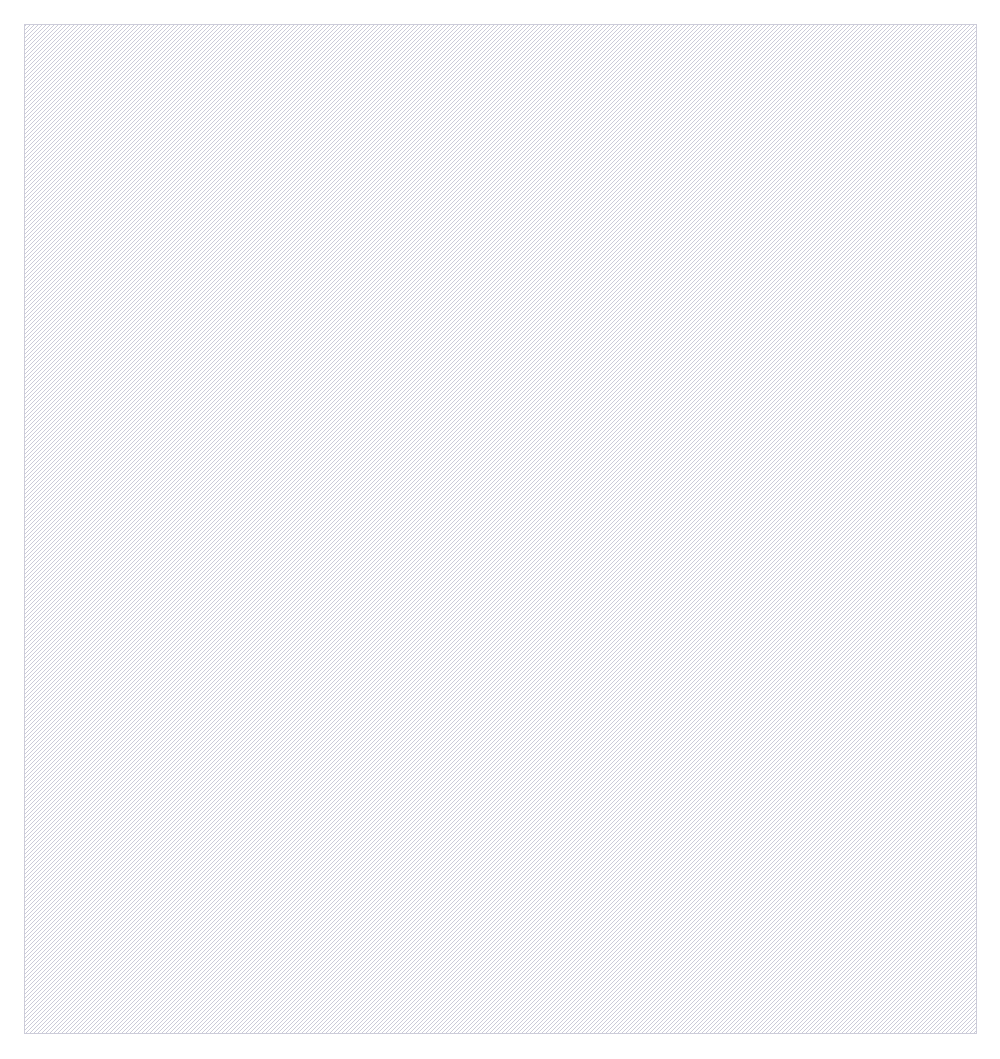

In [11]:
display(floorplan)

### Tap/Endcap Cell Insertion

This places two kinds of cells on the floorplan:

* End cap/boundary cells: Added at the beginning and end of each row. True to
  their name, they "cap off" the core area of a design.
* Tap cells: Placed in a polka dot-ish fashion across the rows. Tap cells
  connect VDD to the nwell and the psubstrate to VSS, which the majority of cells
  do not do themselves to save area- but if you go long enough without one such
  connection you end up with the cell "latching-up"; i.e.; refusing to switch
  back to LO from HI.

  There is a maximum distance between tap cells enforced as part of every
  foundry process.

In [12]:
TapEndcapInsertion = Step.factory.get("OpenROAD.TapEndcapInsertion")

tdi = TapEndcapInsertion(state_in=floorplan.state_out)
tdi.start()

─────────────────────────────────────────────── Tap/Decap Insertion ───────────────────────────────────────────────

[09:21:41] VERBOSE  Running 'OpenROAD.TapEndcapInsertion' at                                           ]8;id=382600;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=426666;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\
                    'librelane_run/3-openroad-tapendcapinsertion'…                                                 

[09:21:41] VERBOSE  Logging subprocess to                                                              ]8;id=293599;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=376464;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/3-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log'…                 

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/3-openroad-tapendcapinsertion/wallace16_n53.nl.v'…

Writing powered netlist to '/content/librelane_run/3-openroad-tapendcapinsertion/wallace16_n53.pnl.v'…

Writing layout to '/content/librelane_run/3-openroad-tapendcapinsertion/wallace16_n53.def'…

Writing timing constraints to '/content/librelane_run/3-openroad-tapendcapinsertion/wallace16_n53.sdc'…

Format,Path
nl,librelane_run/3-openroad-tapendcapinsertion/wallace16_n53.nl.v
odb,librelane_run/3-openroad-tapendcapinsertion/wallace16_n53.odb
def,librelane_run/3-openroad-tapendcapinsertion/wallace16_n53.def
sdc,librelane_run/3-openroad-tapendcapinsertion/wallace16_n53.sdc
pnl,librelane_run/3-openroad-tapendcapinsertion/wallace16_n53.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:21:43] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_dflt0heo'…               ]8;id=252408;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=403107;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:43] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_dflt0heo/klayout-render.log'…  ]8;id=4644;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=969160;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.53s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
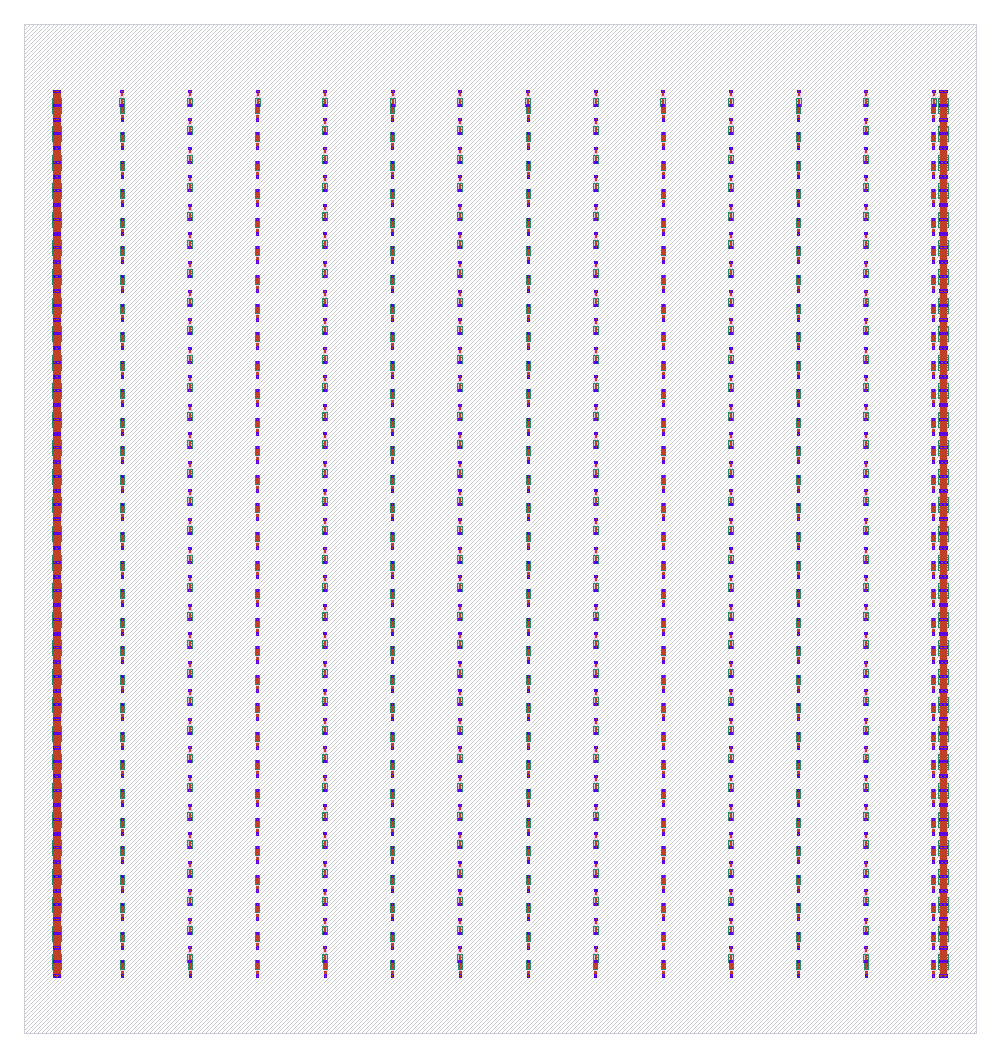

In [13]:
display(tdi)

### I/O Placement

This places metal pins at the edges of the design corresponding to the top level
inputs and outputs for your design. These pins act as the interface with other
designs when you integrate it with other designs.

In [14]:
IOPlacement = Step.factory.get("OpenROAD.IOPlacement")

ioplace = IOPlacement(state_in=tdi.state_out)
ioplace.start()

────────────────────────────────────────────────── I/O Placement ──────────────────────────────────────────────────

[09:21:44] VERBOSE  Running 'OpenROAD.IOPlacement' at 'librelane_run/4-openroad-ioplacement'…          ]8;id=662478;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=793917;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:44] VERBOSE  Logging subprocess to                                                              ]8;id=304536;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=175787;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/4-openroad-ioplacement/openroad-ioplacement.log'…                               

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/4-openroad-ioplacement/wallace16_n53.nl.v'…

Writing powered netlist to '/content/librelane_run/4-openroad-ioplacement/wallace16_n53.pnl.v'…

Writing layout to '/content/librelane_run/4-openroad-ioplacement/wallace16_n53.def'…

Writing timing constraints to '/content/librelane_run/4-openroad-ioplacement/wallace16_n53.sdc'…

Format,Path
nl,librelane_run/4-openroad-ioplacement/wallace16_n53.nl.v
odb,librelane_run/4-openroad-ioplacement/wallace16_n53.odb
def,librelane_run/4-openroad-ioplacement/wallace16_n53.def
sdc,librelane_run/4-openroad-ioplacement/wallace16_n53.sdc
pnl,librelane_run/4-openroad-ioplacement/wallace16_n53.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:21:45] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_29pw2k65'…               ]8;id=578746;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=913839;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:45] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_29pw2k65/klayout-render.log'…  ]8;id=329243;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=526593;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.53s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
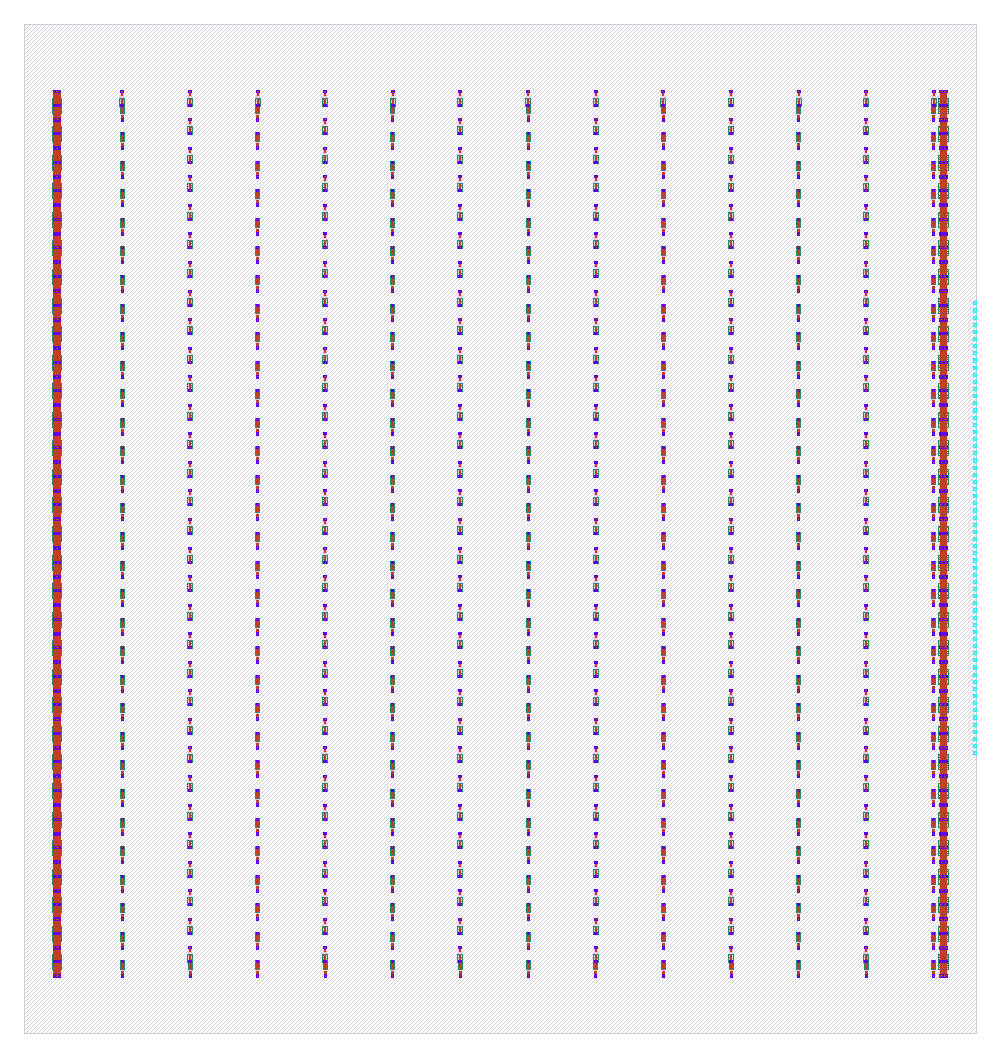

In [15]:
display(ioplace)

### Generating the Power Distribution Network (PDN)

This creates the power distribution network for your design, which is essentially
a plaid pattern of horizontal and vertical "straps" across the design that is
then connected to the rails' VDD and VSS (via the tap cells.)

You can find an explanation of how the power distribution network works at this
link: https://librelane.readthedocs.io/en/latest/usage/hardening_macros.html#pdn-generation

While we typically don't need to mess with the PDN too much, the SPM is a small
design, so we're going to need to make the plaid pattern formed by the PDN a bit
smaller.

In [16]:
GeneratePDN = Step.factory.get("OpenROAD.GeneratePDN")

pdn = GeneratePDN(
    state_in=ioplace.state_out,
    FP_PDN_VWIDTH=2,
    FP_PDN_HWIDTH=2,
    FP_PDN_VPITCH=30,
    FP_PDN_HPITCH=30,
)
pdn.start()

[09:21:46] INFO     Loading the incremental configuration has generated the following warnings:       ]8;id=131444;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=73040;file:///content/librelane_ipynb/librelane/config/config.py#333\333]8;;\

[09:21:46] WARNING  The configuration variable 'FP_PDN_VWIDTH' is deprecated. Please check the docs   ]8;id=388837;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=877799;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_VWIDTH'.                                        

[09:21:46] WARNING  The configuration variable 'FP_PDN_HWIDTH' is deprecated. Please check the docs   ]8;id=50860;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=789566;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_HWIDTH'.                                        

[09:21:46] WARNING  The configuration variable 'FP_PDN_VPITCH' is deprecated. Please check the docs   ]8;id=208007;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=605477;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_VPITCH'.                                        

[09:21:46] WARNING  The configuration variable 'FP_PDN_HPITCH' is deprecated. Please check the docs   ]8;id=987002;file:///content/librelane_ipynb/librelane/config/config.py\config.py]8;;\:]8;id=370675;file:///content/librelane_ipynb/librelane/config/config.py#337\337]8;;\
                    for the usage on the replacement variable 'PDN_HPITCH'.                                        

...

Writing layout to '/content/librelane_run/5-openroad-generatepdn/wallace16_n53.def'…

Writing timing constraints to '/content/librelane_run/5-openroad-generatepdn/wallace16_n53.sdc'…

[INFO PSM-0040] All shapes on net VPWR are connected.

[INFO PSM-0040] All shapes on net VGND are connected.

Format,Path
nl,librelane_run/5-openroad-generatepdn/wallace16_n53.nl.v
odb,librelane_run/5-openroad-generatepdn/wallace16_n53.odb
def,librelane_run/5-openroad-generatepdn/wallace16_n53.def
sdc,librelane_run/5-openroad-generatepdn/wallace16_n53.sdc
pnl,librelane_run/5-openroad-generatepdn/wallace16_n53.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:21:48] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_dqm8dk11'…               ]8;id=130572;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=913132;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:48] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_dqm8dk11/klayout-render.log'…  ]8;id=745398;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=909284;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.64s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
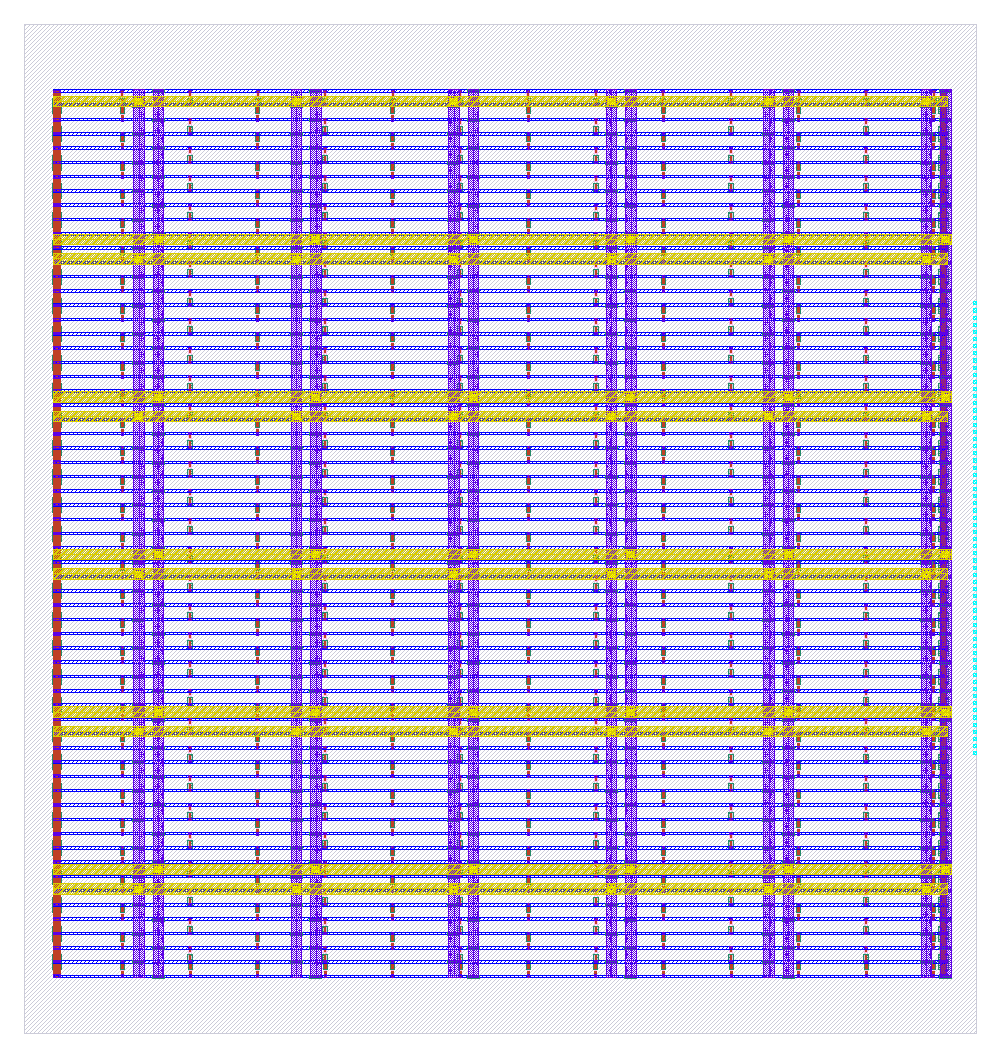

In [17]:
display(pdn)

### Global Placement

Global Placement is deciding on a fuzzy, non-final location for each of the cells,
with the aim of minimizing the distance between cells that are connected
together (more specifically, the total length of the not-yet-created wires that
will connect them).

As you will see in the `.display()` in the second cell below, the placement is
considered "illegal", i.e., not properly aligned with the cell placement grid.
This is addressed by "Detailed Placement", also referred to as "placement
legalization", which is the next step.

In [18]:
GlobalPlacement = Step.factory.get("OpenROAD.GlobalPlacement")

gpl = GlobalPlacement(state_in=pdn.state_out)
gpl.start()

──────────────────────────────────────────────── Global Placement ─────────────────────────────────────────────────

[09:21:49] VERBOSE  Running 'OpenROAD.GlobalPlacement' at 'librelane_run/6-openroad-globalplacement'…  ]8;id=909078;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=90127;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:49] INFO     'PL_TARGET_DENSITY_PCT' not explicitly set, using dynamically calculated       ]8;id=525528;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=485329;file:///content/librelane_ipynb/librelane/steps/openroad.py#1581\1581]8;;\
                    target density: 62.358300…                                                                     

[09:21:49] VERBOSE  Logging subprocess to                                                              ]8;id=339351;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=664821;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/6-openroad-globalplacement/openroad-globalplacement.log'…                       

Reading timing models for corner nom_tt_025C_1v80…

...

Writing netlist to '/content/librelane_run/6-openroad-globalplacement/wallace16_n53.nl.v'…

Writing powered netlist to '/content/librelane_run/6-openroad-globalplacement/wallace16_n53.pnl.v'…

Writing layout to '/content/librelane_run/6-openroad-globalplacement/wallace16_n53.def'…

Writing timing constraints to '/content/librelane_run/6-openroad-globalplacement/wallace16_n53.sdc'…

Format,Path
nl,librelane_run/6-openroad-globalplacement/wallace16_n53.nl.v
odb,librelane_run/6-openroad-globalplacement/wallace16_n53.odb
def,librelane_run/6-openroad-globalplacement/wallace16_n53.def
sdc,librelane_run/6-openroad-globalplacement/wallace16_n53.sdc
pnl,librelane_run/6-openroad-globalplacement/wallace16_n53.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:21:52] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_sk0tjiw0'…               ]8;id=910450;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=102020;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:52] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_sk0tjiw0/klayout-render.log'…  ]8;id=632404;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=535321;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 3.47s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
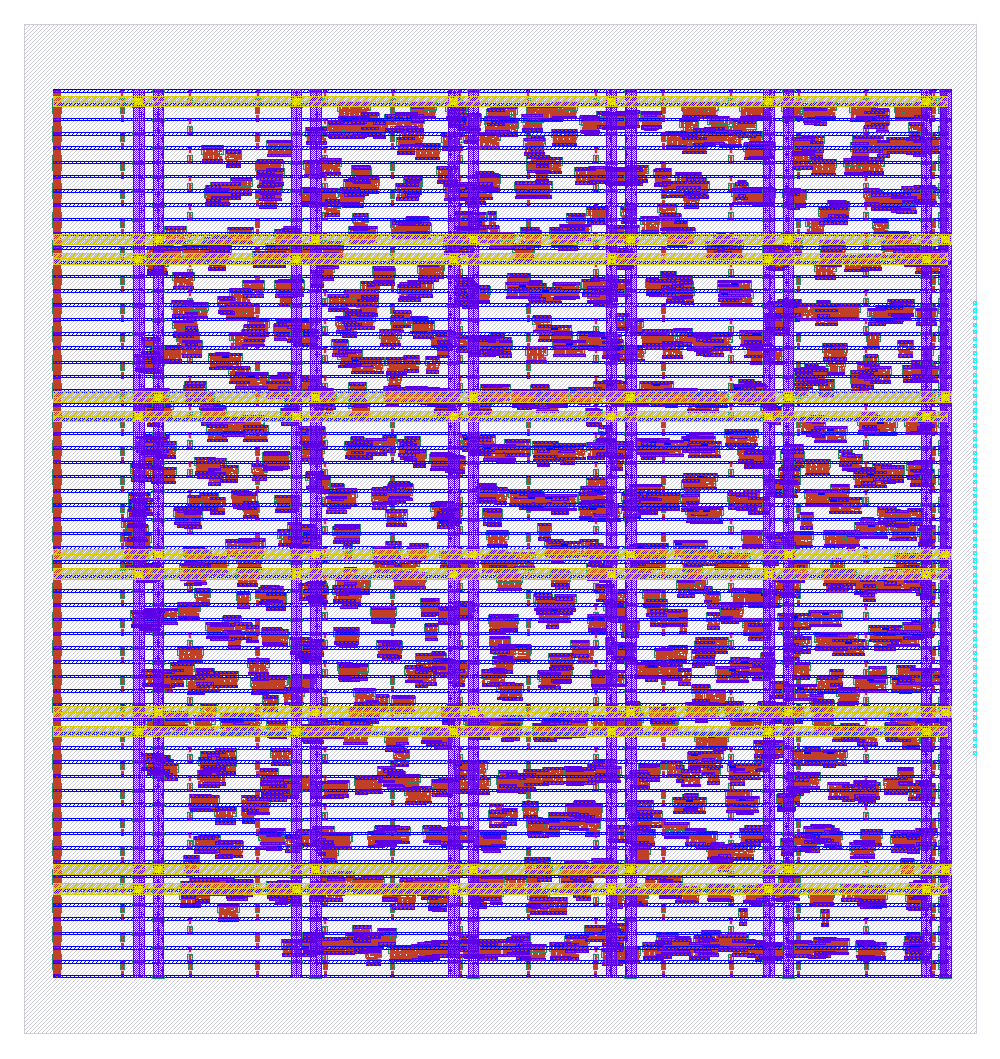

In [19]:
display(gpl)

### Detailed Placement

This aligns the fuzzy placement from before with the grid, "legalizing" it.

In [20]:
DetailedPlacement = Step.factory.get("OpenROAD.DetailedPlacement")

dpl = DetailedPlacement(state_in=gpl.state_out)
dpl.start()

─────────────────────────────────────────────── Detailed Placement ────────────────────────────────────────────────

[09:21:53] VERBOSE  Running 'OpenROAD.DetailedPlacement' at                                            ]8;id=320191;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=108782;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\
                    'librelane_run/7-openroad-detailedplacement'…                                                  

[09:21:53] VERBOSE  Logging subprocess to                                                              ]8;id=408686;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=456156;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/7-openroad-detailedplacement/openroad-detailedplacement.log'…                   

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/7-openroad-detailedplacement/wallace16_n53.nl.v'…

Writing powered netlist to '/content/librelane_run/7-openroad-detailedplacement/wallace16_n53.pnl.v'…

Writing layout to '/content/librelane_run/7-openroad-detailedplacement/wallace16_n53.def'…

Writing timing constraints to '/content/librelane_run/7-openroad-detailedplacement/wallace16_n53.sdc'…

Format,Path
nl,librelane_run/7-openroad-detailedplacement/wallace16_n53.nl.v
odb,librelane_run/7-openroad-detailedplacement/wallace16_n53.odb
def,librelane_run/7-openroad-detailedplacement/wallace16_n53.def
sdc,librelane_run/7-openroad-detailedplacement/wallace16_n53.sdc
pnl,librelane_run/7-openroad-detailedplacement/wallace16_n53.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:21:55] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_qmcaxxnx'…               ]8;id=199583;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=385067;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:55] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_qmcaxxnx/klayout-render.log'…  ]8;id=503546;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=353465;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.84s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
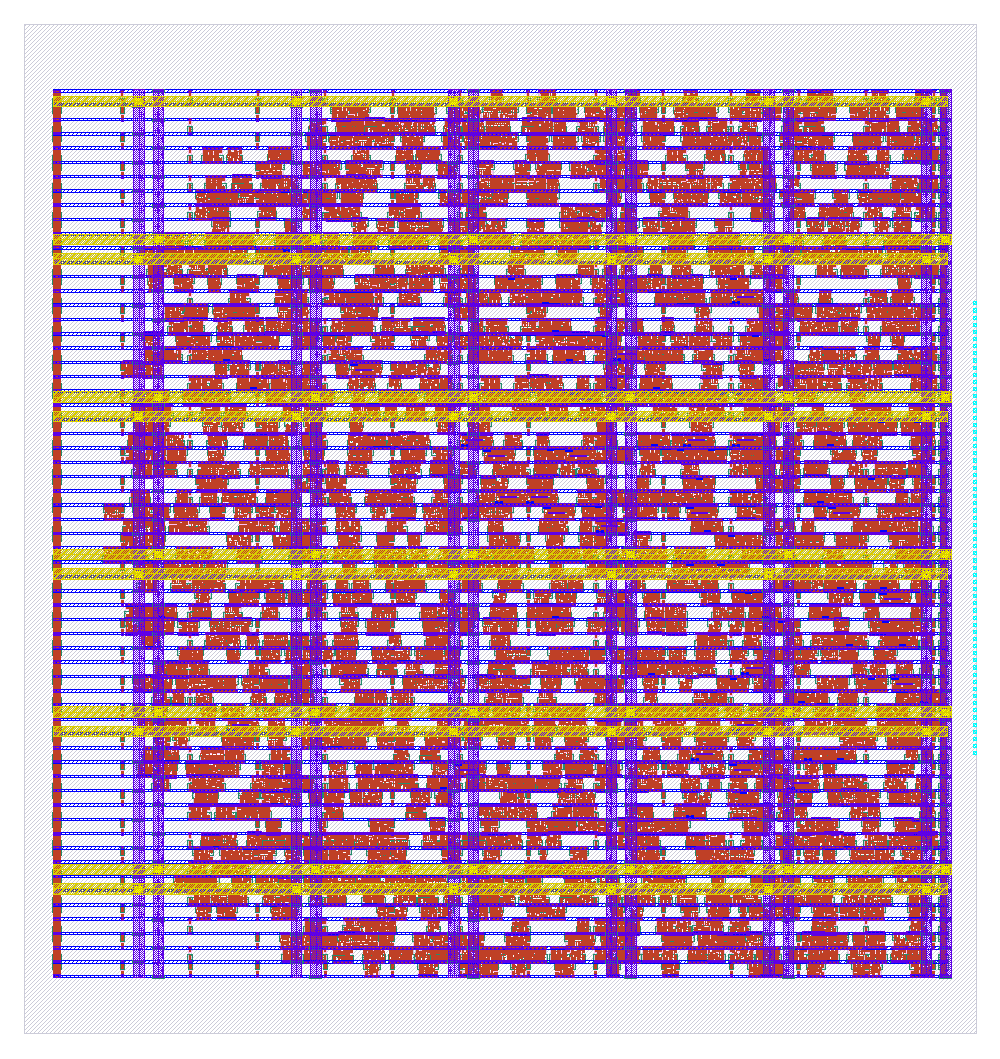

In [21]:
display(dpl)

### Clock Tree Synthesis (CTS)

With the cells now having a final placement, we can go ahead and create what
is known as the clock tree, i.e., the hierarchical set of buffers used
for clock signal to minimize what is known as "clock skew"- variable delay
of the clock cycle from register to register because of factors such as metal
wire length, clock load (number of gates connected to the same clock buffer,)
et cetera.

The CTS step creates the cells and places the between the gaps in the detailed
placement above.

In [22]:
CTS = Step.factory.get("OpenROAD.CTS")

cts = CTS(state_in=dpl.state_out)
cts.start()

────────────────────────────────────────────── Clock Tree Synthesis ───────────────────────────────────────────────

[09:21:56] VERBOSE  Running 'OpenROAD.CTS' at 'librelane_run/8-openroad-cts'…                          ]8;id=436960;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=97601;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:21:56] VERBOSE  Logging subprocess to 'librelane_run/8-openroad-cts/openroad-cts.log'…             ]8;id=479633;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=204135;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Reading timing models for corner max_tt_025C_1v80…

Reading timing library for the 'max_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/8-openroad-cts/wallace16_n53.nl.v'…

Writing powered netlist to '/content/librelane_run/8-openroad-cts/wallace16_n53.pnl.v'…

Writing layout to '/content/librelane_run/8-openroad-cts/wallace16_n53.def'…

Writing timing constraints to '/content/librelane_run/8-openroad-cts/wallace16_n53.sdc'…

Format,Path
nl,librelane_run/8-openroad-cts/wallace16_n53.nl.v
odb,librelane_run/8-openroad-cts/wallace16_n53.odb
def,librelane_run/8-openroad-cts/wallace16_n53.def
sdc,librelane_run/8-openroad-cts/wallace16_n53.sdc
pnl,librelane_run/8-openroad-cts/wallace16_n53.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:22:26] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_p033n74f'…               ]8;id=196156;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=856422;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:22:26] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_p033n74f/klayout-render.log'…  ]8;id=204457;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=597038;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 29.90s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
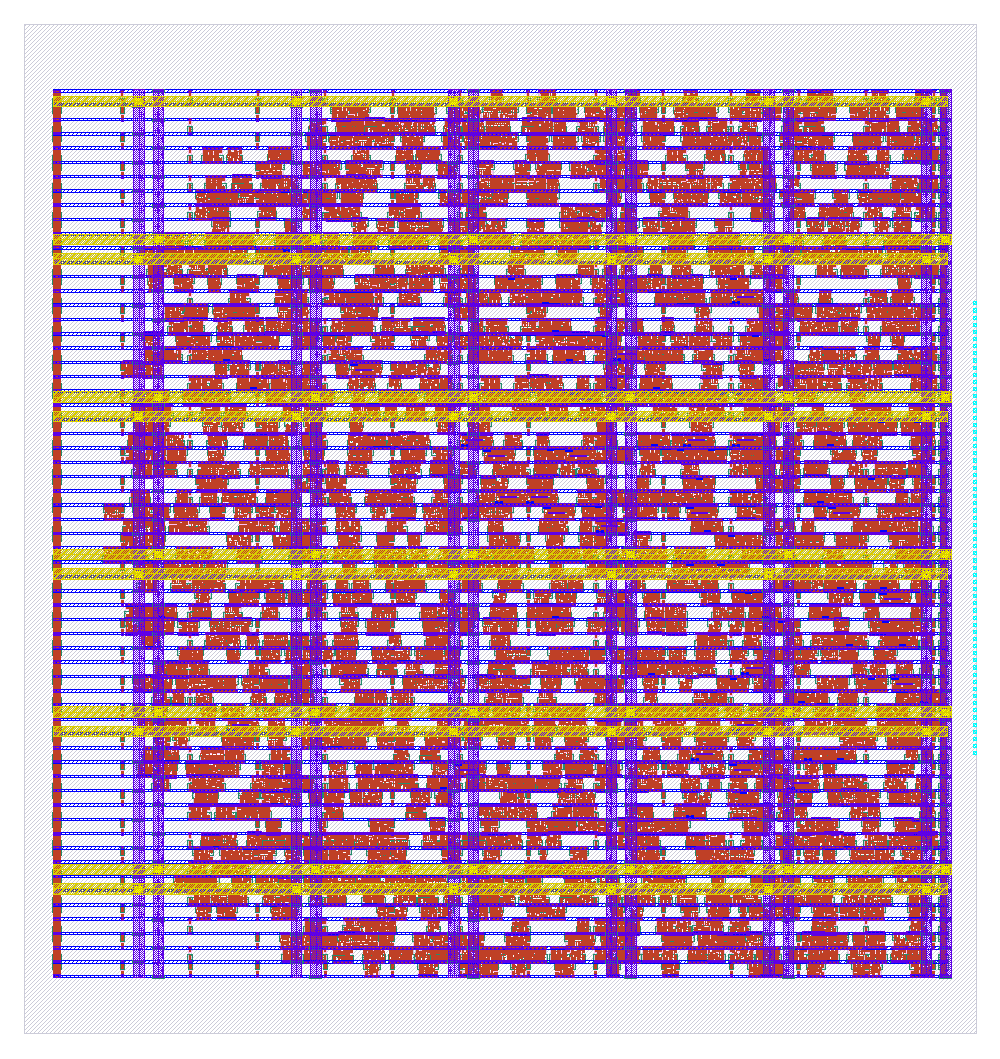

In [23]:
display(cts)

### Global Routing

Global routing "plans" the routes the wires between two gates (or gates and
I/O pins/the PDN) will take. The results of global routing (which are called
"routing guides") are stored in internal data structures and have no effect on
the actual design, so there is no `display()` statement.

In [24]:
GlobalRouting = Step.factory.get("OpenROAD.GlobalRouting")

grt = GlobalRouting(state_in=cts.state_out)
grt.start()

───────────────────────────────────────────────── Global Routing ──────────────────────────────────────────────────

[09:22:27] VERBOSE  Running 'OpenROAD.GlobalRouting' at 'librelane_run/9-openroad-globalrouting'…      ]8;id=458878;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=282924;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:22:27] VERBOSE  Logging subprocess to                                                              ]8;id=723610;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=247078;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/9-openroad-globalrouting/openroad-globalrouting.log'…                           

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Multi-Input combinational cell         1509   14405.07

Total                                  2076   15493.61

Writing OpenROAD database to '/content/librelane_run/9-openroad-globalrouting/wallace16_n53.odb'…

Writing layout to '/content/librelane_run/9-openroad-globalrouting/wallace16_n53.def'…

Format,Path
nl,librelane_run/8-openroad-cts/wallace16_n53.nl.v
odb,librelane_run/9-openroad-globalrouting/wallace16_n53.odb
def,librelane_run/9-openroad-globalrouting/wallace16_n53.def
sdc,librelane_run/8-openroad-cts/wallace16_n53.sdc
pnl,librelane_run/8-openroad-cts/wallace16_n53.pnl.v


### Detailed Routing

Detailed routing uses the guides from Global Routing to actually create wires
on the metal layers and connect the gates, making the connections finally physical.

This is typically the longest step in the flow.

In [25]:
DetailedRouting = Step.factory.get("OpenROAD.DetailedRouting")

drt = DetailedRouting(state_in=grt.state_out)
drt.start()

──────────────────────────────────────────────── Detailed Routing ─────────────────────────────────────────────────

[09:22:30] VERBOSE  Running 'OpenROAD.DetailedRouting' at 'librelane_run/10-openroad-detailedrouting'… ]8;id=745884;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=271279;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:22:30] INFO     Running TritonRoute with 2 threads…                                            ]8;id=389249;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=742258;file:///content/librelane_ipynb/librelane/steps/openroad.py#2002\2002]8;;\

[09:22:30] VERBOSE  Logging subprocess to                                                              ]8;id=760484;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=421134;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/10-openroad-detailedrouting/openroad-detailedrouting.log'…                      

Reading timing models for corner nom_tt_025C_1v80…

...

Writing netlist to '/content/librelane_run/10-openroad-detailedrouting/wallace16_n53.nl.v'…

Writing powered netlist to '/content/librelane_run/10-openroad-detailedrouting/wallace16_n53.pnl.v'…

Writing layout to '/content/librelane_run/10-openroad-detailedrouting/wallace16_n53.def'…

Writing timing constraints to '/content/librelane_run/10-openroad-detailedrouting/wallace16_n53.sdc'…

Format,Path
nl,librelane_run/10-openroad-detailedrouting/wallace16_n53.nl.v
odb,librelane_run/10-openroad-detailedrouting/wallace16_n53.odb
def,librelane_run/10-openroad-detailedrouting/wallace16_n53.def
sdc,librelane_run/10-openroad-detailedrouting/wallace16_n53.sdc
pnl,librelane_run/10-openroad-detailedrouting/wallace16_n53.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:27:16] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_7vboe89y'…               ]8;id=904415;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=839373;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:27:16] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_7vboe89y/klayout-render.log'…  ]8;id=220859;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=338981;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 285.91s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
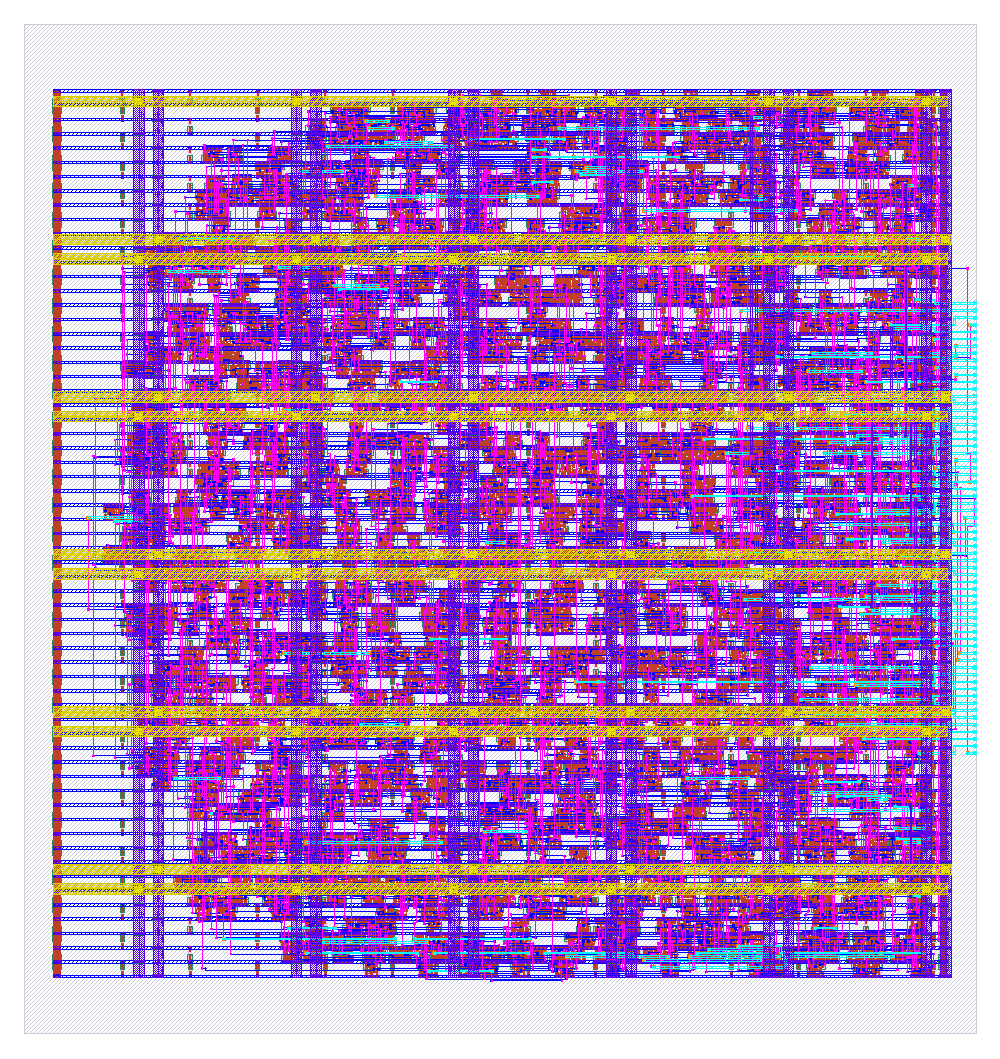

In [26]:
display(drt)

### Fill Insertion

Finally, as we're done placing all the essential cells, the only thing left to
do is fill in the gaps.

We prioritize the use of decap (decoupling capacitor) cells, which
further supports the power distribution network, but when there aren't any
small enough cells, we just use regular fill cells.

In [27]:
FillInsertion = Step.factory.get("OpenROAD.FillInsertion")

fill = FillInsertion(state_in=drt.state_out)
fill.start()

───────────────────────────────────────────────── Fill Insertion ──────────────────────────────────────────────────

[09:27:17] VERBOSE  Running 'OpenROAD.FillInsertion' at 'librelane_run/11-openroad-fillinsertion'…     ]8;id=174558;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=819088;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:27:17] VERBOSE  Logging subprocess to                                                              ]8;id=743345;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=194986;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/11-openroad-fillinsertion/openroad-fillinsertion.log'…                          

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.nl.v'…

Writing powered netlist to '/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.pnl.v'…

Writing layout to '/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.def'…

Writing timing constraints to '/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.sdc'…

Format,Path
nl,librelane_run/11-openroad-fillinsertion/wallace16_n53.nl.v
odb,librelane_run/11-openroad-fillinsertion/wallace16_n53.odb
def,librelane_run/11-openroad-fillinsertion/wallace16_n53.def
sdc,librelane_run/11-openroad-fillinsertion/wallace16_n53.sdc
pnl,librelane_run/11-openroad-fillinsertion/wallace16_n53.pnl.v


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:27:19] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_kt1_6asu'…               ]8;id=166395;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=759698;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:27:19] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_kt1_6asu/klayout-render.log'…  ]8;id=269849;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=84021;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 1.84s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
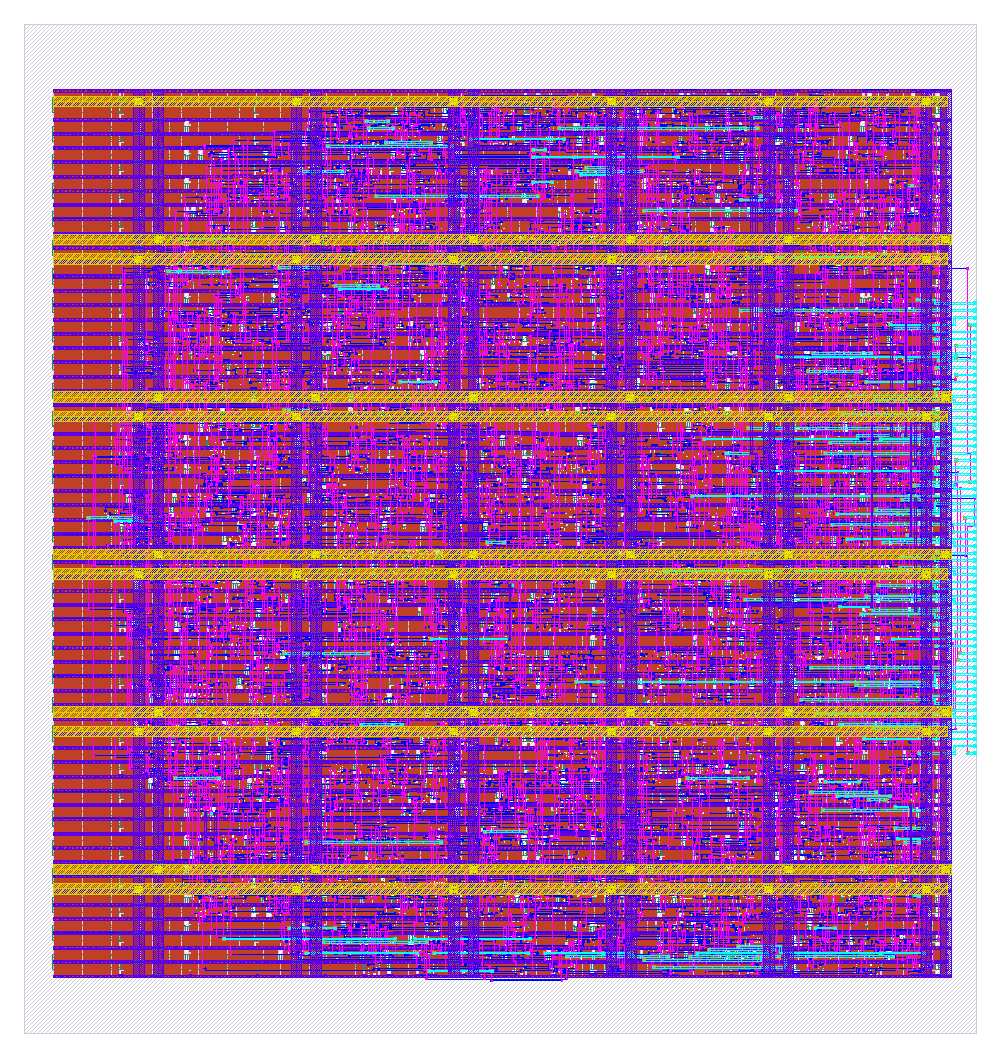

In [28]:
display(fill)

### Parasitics Extraction a.k.a. Resistance/Capacitance Extraction (RCX)

This step does not alter the design- rather, it computes the
[Parasitic elements](https://en.wikipedia.org/wiki/Parasitic_element_(electrical_networks))
of the circuit, which have an effect of timing, as we prepare to do the final
timing analysis.

The parasitic elements are saved in the **Standard Parasitics Exchange Format**,
or SPEF. LibreLane creates a SPEF file for each interconnect corner as described in
the [Corners and STA](https://librelane.readthedocs.io/en/latest/usage/corners_and_sta.html)
section of the documentation.

In [29]:
RCX = Step.factory.get("OpenROAD.RCX")

rcx = RCX(state_in=fill.state_out)
rcx.start()

─────────────────────────────────── Parasitic Resistance/Capacitance Extraction ───────────────────────────────────

[09:27:20] VERBOSE  Running 'OpenROAD.RCX' at 'librelane_run/12-openroad-rcx'…                         ]8;id=275285;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=898627;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:27:20] INFO     Running RCX for corners matching nom_*                                         ]8;id=166662;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=634282;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/12-openroad-rcx/nom/rcx.log)…                                          

[09:27:20] INFO     Running RCX for corners matching min_*                                         ]8;id=618987;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=598837;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/12-openroad-rcx/min/rcx.log)…                                          

[09:27:20] VERBOSE  Logging subprocess to 'librelane_run/12-openroad-rcx/nom/rcx.log'…                 ]8;id=310664;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=506512;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

...

[09:27:22] INFO     Running RCX for corners matching max_*                                         ]8;id=925657;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=950236;file:///content/librelane_ipynb/librelane/steps/openroad.py#2145\2145]8;;\
                    (/content/librelane_run/12-openroad-rcx/max/rcx.log)…                                          

[09:27:22] INFO     Finished RCX for corners matching min_*.                                       ]8;id=845013;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=486845;file:///content/librelane_ipynb/librelane/steps/openroad.py#2154\2154]8;;\

[09:27:22] VERBOSE  Logging subprocess to 'librelane_run/12-openroad-rcx/max/rcx.log'…                 ]8;id=902313;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=238288;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

[09:27:23] INFO     Finished RCX for corners matching max_*.                                       ]8;id=108910;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=609980;file:///content/librelane_ipynb/librelane/steps/openroad.py#2154\2154]8;;\

{'nl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.nl.v'), 'odb': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.odb'), 'def': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.def'), 'sdc': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.sdc'), 'pnl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/12-openroad-rcx/nom/wallace16_n53.nom.spef'), 'min_*': Path('/content/librelane_run/12-openroad-rcx/min/wallace16_n53.min.spef'), 'max_*': Path('/content/librelane_run/12-openroad-rcx/max/wallace16_n53.max.spef')}, 'metrics': {'design__instance__count': 6037, 'design__instance__area': Decimal('28702.5'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 6, 'design__die__bbox': '0.0 0.0 181.38 192.1', 'design__core__bbox': '5.52 10.88 175.72 179.52', 'design__io': 66, 'design__die__area': Decimal('34843.1'), 'design__core__area': Decimal('28702.5'), 'design__instance__count__stdcell': 1952, 'design__instance__area__stdcell': Decimal('15028.2'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.523583'), 'design__instance__utilization__stdcell': Decimal('0.523583'), 'design__rows': 62, 'design__rows:unithd': 62, 'design__sites': 22940, 'design__sites:unithd': 22940, 'design__instance__count__class:buffer': 1, 'design__instance__area__class:buffer': Decimal('5.0048'), 'design__instance__count__class:inverter': 26, 'design__instance__area__class:inverter': Decimal('97.5936'), 'design__instance__count__class:multi_input_combinational_cell': 1509, 'design__instance__area__class:multi_input_combinational_cell': Decimal('14405.1'), 'flow__warnings__count': 4, 'flow__errors__count': 0, 'flow__warnings__count:ODB-0220': 2, 'flow__warnings__count:STA-0366': 2, 'flow__warnings__count:STA-0419': 1, 'flow__warnings__count:STA-0450': 1, 'flow__warnings__type_count': 3, 'design__instance__count__class:fill_cell': 4085, 'design__instance__area__class:fill_cell': Decimal('13674.4'), 'design__instance__count__class:tap_cell': 416, 'design__instance__area__class:tap_cell': Decimal('520.499'), 'floorplan__design__io': 64, 'design__io__hpwl': 7196800, 'design__power_grid_violation__count__net:VPWR': 0, 'design__power_grid_violation__count__net:VGND': 0, 'design__power_grid_violation__count': 0, 'design__instance__displacement__total': 0, 'design__instance__displacement__mean': 0, 'design__instance__displacement__max': 0, 'route__wirelength__estimated': Decimal('29860.2'), 'design__violations': 0, 'flow__warnings__count:CTS-0082': 1, 'flow__warnings__count:CTS-0083': 1, 'flow__warnings__count:STA-1140': 6, 'global_route__vias': 11416, 'global_route__wirelength': 61499, 'route__net': 1568, 'route__net__special': 2, 'route__drc_errors__iter:0': 619, 'route__wirelength__iter:0': 39041, 'route__drc_errors__iter:1': 172, 'route__wirelength__iter:1': 38650, 'route__drc_errors__iter:2': 225, 'route__wirelength__iter:2': 38608, 'route__drc_errors__iter:3': 0, 'route__wirelength__iter:3': 38538, 'route__drc_errors': 0, 'route__wirelength': 38538, 'route__vias': 12908, 'route__vias__singlecut': 12908, 'route__vias__multicut': 0, 'antenna__violating__nets': 0, 'antenna__violating__pins': 0, 'flow__warnings__count:DRT-0349': 10}}

### Static Timing Analysis (Post-PnR)

STA is a process that verifies that a chip meets certain constraints on clock
and data timings to run at its rated clock speed. See [Corners and STA](https://librelane.readthedocs.io/en/latest/usage/corners_and_sta.html)
in the documentation for more info.

---

This step generates two kinds of files:
* `.lib`: Liberty™-compatible Library files. Can be used to do static timing
  analysis when creating a design with this design as a sub-macro.
* `.sdf`: Standard Delay Format. Can be used with certain simulation software
  to do *dynamic* timing analysis.

Unfortunately, the `.lib` files coming out of LibreLane right now are not super
reliable for timing purposes and are only provided for completeness.

When using LibreLane-created macros withing other designs, it is best to use the
macro's final netlist and extracted parasitics instead.

In [30]:
STAPostPNR = Step.factory.get("OpenROAD.STAPostPNR")

sta_post_pnr = STAPostPNR(state_in=rcx.state_out)
sta_post_pnr.start()

──────────────────────────────────────── Static Timing Analysis (Post-PnR) ────────────────────────────────────────

[09:27:23] VERBOSE  Running 'OpenROAD.STAPostPNR' at 'librelane_run/13-openroad-stapostpnr'…           ]8;id=469048;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=317858;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:27:23] INFO     Starting STA for the nom_tt_025C_1v80 timing corner…                            ]8;id=799627;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=274430;file:///content/librelane_ipynb/librelane/steps/openroad.py#747\747]8;;\

[09:27:23] INFO     Starting STA for the nom_ss_100C_1v60 timing corner…                            ]8;id=441534;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=382920;file:///content/librelane_ipynb/librelane/steps/openroad.py#747\747]8;;\

[09:27:23] VERBOSE  Logging subprocess to                                                              ]8;id=827922;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=764886;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/sta.log'…                               

...

[09:27:52] INFO     Finished STA for the max_ff_n40C_1v95 timing corner.                            ]8;id=640087;file:///content/librelane_ipynb/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=481171;file:///content/librelane_ipynb/librelane/steps/openroad.py#762\762]8;;\

[09:27:52] VERBOSE  Logging subprocess to                                                              ]8;id=762005;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=754604;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/filter_unannotated.log'…                

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┓
┃                      ┃       ┃       ┃      ┃       ┃ of   ┃       ┃      ┃       ┃      ┃ of    ┃      ┃       ┃
┃                      ┃       ┃ Reg   ┃      ┃       ┃ whi… ┃       ┃ Reg  ┃       ┃      ┃ which ┃      ┃       ┃
┃                      ┃ Hold  ┃ to    ┃      ┃ Hold  ┃ reg  ┃ Setup ┃ to   ┃       ┃ Set… ┃ reg   ┃ Max  ┃ Max   ┃
┃                      ┃ Worst ┃ Reg   ┃ Hold ┃ Vio   ┃ to   ┃ Worst ┃ Reg  ┃ Setup ┃ Vio  ┃ to    ┃ Cap  ┃ Slew  ┃
┃ Corner/Group         ┃ Slack ┃ Paths ┃ TNS  ┃ Count ┃ reg  ┃ Slack ┃ Pat… ┃ TNS   ┃ Cou… ┃ reg   ┃ Vio… ┃ Viol… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━┩
│ Overall              │ 4.09… │ N/A   │ 0.0… │ 0     │ 0    │ -8.3… │ N/A  │ -154… │ 123  │ 0     │ 7    │ 1163  │
│ nom_tt_025C_1v80     │ 4.33… │ N/A   │ 0.0… │ 0     │ 0    │ -1.0… │ N/A  │ -8.6… │ 15   │ 0     │ 1    │ 868   │
│ nom_ss_100C_1v60     │ 4.83… │ N/A   │ 0.0… │ 0     │ 0    │ -8.2… │ N/A  │ -150… │ 25   │ 0     │ 1    │ 1157  │
│ nom_ff_n40C_1v95     │ 4.10… │ N/A   │ 0.0… │ 0     │ 0    │ 1.61… │ N/A  │ 0.00… │ 0    │ 0     │ 2    │ 0     │
│ min_tt_025C_1v80     │ 4.31… │ N/A   │ 0.0… │ 0     │ 0    │ -0.9… │ N/A  │ -7.5… │ 15   │ 0     │ 1    │ 594   │
│ min_ss_100C_1v60     │ 4.80… │ N/A   │ 0.0… │ 0     │ 0    │ -8.0… │ N/A  │ -147… │ 25   │ 0     │ 0    │ 1157  │
│ min_ff_n40C_1v95     │ 4.09… │ N/A   │ 0.0… │ 0     │ 0    │ 1.67… │ N/A  │ 0.00… │ 0    │ 0     │ 1    │ 0     │
│ max_tt_025C_1v80     │ 4.34… │ N/A   │ 0.0… │ 0     │ 0    │ -1.1… │ N/A  │ -10.… │ 18   │ 0     │ 5    │ 934   │
│ max_ss_100C_1v60     │ 4.86… │ N/A   │ 0.0… │ 0     │ 0    │ -8.3… │ N/A  │ -154… │ 25   │ 0     │ 5    │ 1163  │
│ max_ff_n40C_1v95     │ 4.11… │ N/A   │ 0.0… │ 0     │ 0    │ 1.54… │ N/A  │ 0.00… │ 0    │ 0     │ 7    │ 42    │
└──────────────────────┴───────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┘

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃                      ┃ Hold     ┃ Reg to   ┃          ┃          ┃ of which  ┃ Setup    ┃           ┃          ┃           ┃ of which ┃           ┃          ┃
┃                      ┃ Worst    ┃ Reg      ┃          ┃ Hold Vio ┃ reg to    ┃ Worst    ┃ Reg to    ┃ Setup    ┃ Setup Vio ┃ reg to   ┃ Max Cap   ┃ Max Slew ┃
┃ Corner/Group         ┃ Slack    ┃ Paths    ┃ Hold TNS ┃ Count    ┃ reg       ┃ Slack    ┃ Reg Paths ┃ TNS      ┃ Count     ┃ reg      ┃ Violatio… ┃ Violati… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ Overall              │ 4.0952   │ N/A      │ 0.0000   │ 0        │ 0         │ -8.3905  │ N/A       │ -154.36… │ 123       │ 0        │ 7         │ 1163     │
│ nom_tt_025C_1v80     │ 4.3317   │ N/A      │ 0.0000   │ 0        │ 0         │ -1.0564  │ N/A       │ -8.6941  │ 15        │ 0        │ 1         │ 868      │
│ nom_ss_100C_1v60     │ 4.8361   │ N/A      │ 0.0000   │ 0        │ 0         │ -8.2175  │ N/A       │ -150.98… │ 25        │ 0        │ 1         │ 1157     │
│ nom_ff_n40C_1v95     │ 4.1051   │ N/A      │ 0.0000   │ 0        │ 0         │ 1.6199   │ N/A       │ 0.0000   │ 0         │ 0        │ 2         │ 0        │
│ min_tt_025C_1v80     │ 4.3172   │ N/A      │ 0.0000   │ 0        │ 0         │ -0.9701  │ N/A       │ -7.5430  │ 15        │ 0        │ 1         │ 594      │
│ min_ss_100C_1v60     │ 4.8094   │ N/A      │ 0.0000   │ 0        │ 0         │ -8.0657  │ N/A       │ -147.79… │ 25        │ 0        │ 0         │ 1157     │
│ min_ff_n40C_1v95     │ 4.0952   │ N/A      │ 0.0000   │ 0        │ 0         │ 1.6792   │ N/A       │ 0.0000   │ 0         │ 0        │ 1         │ 0        │
│ max_tt_025C_1v80     │ 4.3449   │ N/A      │ 0.0000   │ 0        │ 0         │ -1.1572  │ N/A       │ -10.1388 │ 18        │ 0        │ 5         │ 934      │
│ max_ss_100C_1v60     │ 4.8613   │ N/A      │ 0.0000   │ 0        │ 0         │ -8.3905  │ N/A       │ -154.36… │ 25        │ 0        │ 5         │ 1163     │
│ max_ff_n40C_1v95     │ 4.1139   │ N/A      │ 0.0000   │ 0        │ 0         │ 1.5477   │ N/A       │ 0.0000   │ 0         │ 0        │ 7         │ 42       │
└──────────────────────┴──────────┴──────────┴──────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┘

{'nl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.nl.v'), 'odb': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.odb'), 'def': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.def'), 'sdc': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.sdc'), 'pnl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/12-openroad-rcx/nom/wallace16_n53.nom.spef'), 'min_*': Path('/content/librelane_run/12-openroad-rcx/min/wallace16_n53.min.spef'), 'max_*': Path('/content/librelane_run/12-openroad-rcx/max/wallace16_n53.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.lib')}, 'metrics': {'design__instance__count': 6037, 'design__instance__area': Decimal('28702.5'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 6, 'design__die__bbox': '0.0 0.0 181.38 192.1', 'design__core__bbox': '5.52 10.88 175.72 179.52', 'design__io': 66, 'design__die__area': Decimal('34843.1'), 'design__core__area': Decimal('28702.5'), 'design__instance__count__stdcell': 1952, 'design__instance__area__stdcell': Decimal('15028.2'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.523583'), 'design__instance__utilization__stdcell': Decimal('0.523583'), 'design__rows': 62, 'design__rows:unithd': 62, 'design__sites': 22940, 'design__sites:unithd': 22940, 'design__instance__count__class:buffer': 1, 'design__instance__area__class:buffer': Decimal('

### Stream-out

Stream-out is the process of converting the designs from the abstract formats
using during floorplanning, placement and routing into a concrete format called
GDSII (lit. Graphic Design System 2), which is the final file that is then sent
for fabrication.

In [31]:
StreamOut = Step.factory.get("KLayout.StreamOut")

gds = StreamOut(state_in=sta_post_pnr.state_out)
gds.start()

─────────────────────────────────────────── GDSII Stream Out (KLayout) ────────────────────────────────────────────

[09:27:53] VERBOSE  Running 'KLayout.StreamOut' at 'librelane_run/14-klayout-streamout'…               ]8;id=523145;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=160717;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:27:53] VERBOSE  Logging subprocess to 'librelane_run/14-klayout-streamout/klayout-streamout.log'…  ]8;id=460254;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=74576;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

[INFO] Clearing cells…

[INFO] Merging GDS files…

...

[INFO] Checking for missing GDS…

[INFO] All LEF cells have matching GDS cells.

[INFO] Writing out GDS '/content/librelane_run/14-klayout-streamout/wallace16_n53.klayout.gds'…

[INFO] Done.

{'nl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.nl.v'), 'odb': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.odb'), 'def': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.def'), 'sdc': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.sdc'), 'pnl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/12-openroad-rcx/nom/wallace16_n53.nom.spef'), 'min_*': Path('/content/librelane_run/12-openroad-rcx/min/wallace16_n53.min.spef'), 'max_*': Path('/content/librelane_run/12-openroad-rcx/max/wallace16_n53.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/14-klayout-streamout/wallace16_n53.klayout.gds'), 'gds': Path('/content/librelane_run/14-klayout-streamout/wallace16_n53.gds'), 'metrics': {'design__instance__count': 6037, 'design__instance__area': Decimal('28702.5'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 6, 'design__die__bbox': '0.0 0.0 181.38 192.1', 'design__core__bbox': '5.52 10.88 175.72 179.52', 'design__io': 66, 'design__die__area': Decimal('34843.1'), 'design__core__area': Decimal('28702.5'), 'design__instance__count__stdcell': 1952, 'design__instance__area__stdcell': Decimal('15028.2'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.523583'), 'design__instance__utilization__stdcell': Decimal('0.523583'), 'design__rows': 62, 'de

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[09:27:54] VERBOSE  Running 'KLayout.Render' at '../tmp/librelane_klayout_tmp_tl5nic2y'…               ]8;id=482988;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=20535;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:27:54] VERBOSE  Logging subprocess to '../tmp/librelane_klayout_tmp_tl5nic2y/klayout-render.log'…  ]8;id=614130;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=472048;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

#### Time Elapsed: 0.71s
#### Views updated:
* GDSII Stream (KLayout)
* GDSII Stream
#### Preview:
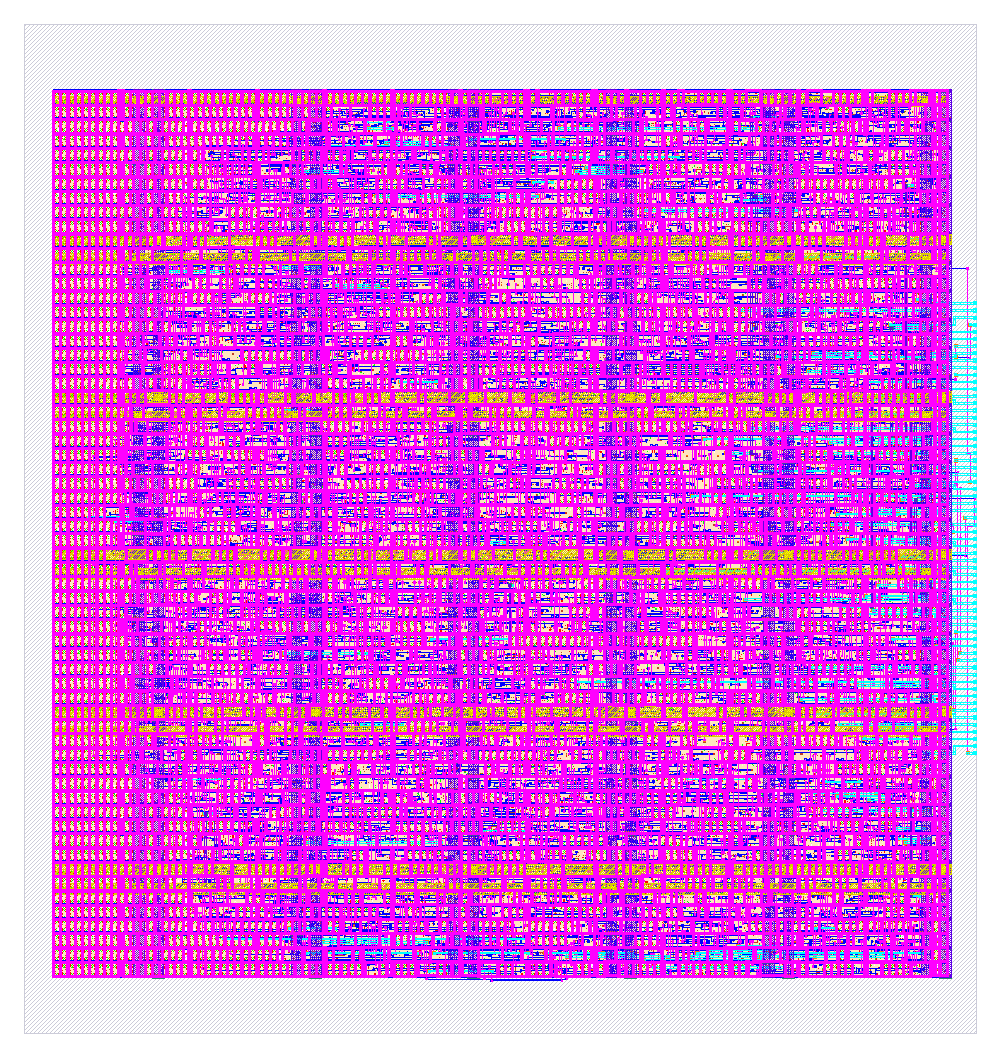

In [32]:
display(gds)

In [33]:
DRC = Step.factory.get("Magic.DRC")

drc = DRC(state_in=gds.state_out)
drc.start()

─────────────────────────────────────────────── Design Rule Checks ────────────────────────────────────────────────

[09:27:55] VERBOSE  Running 'Magic.DRC' at 'librelane_run/15-magic-drc'…                               ]8;id=786444;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=345686;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:27:55] VERBOSE  Logging subprocess to 'librelane_run/15-magic-drc/magic-drc.log'…                  ]8;id=52659;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=976293;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Magic 8.3 revision 623 - Compiled on Tue Mar 17 08:19:38 UTC 2026.

Starting magic under Tcl interpreter

...

[INFO] Should be divided by 3 or 4

[INFO] DRC Checking DONE (/content/librelane_run/15-magic-drc/reports/drc.magic.rpt)

[INFO] Saving mag view with DRC errors (/content/librelane_run/15-magic-drc/views/wallace16_n53.drc.mag)

[INFO] Saved

{'nl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.nl.v'), 'odb': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.odb'), 'def': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.def'), 'sdc': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.sdc'), 'pnl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/12-openroad-rcx/nom/wallace16_n53.nom.spef'), 'min_*': Path('/content/librelane_run/12-openroad-rcx/min/wallace16_n53.min.spef'), 'max_*': Path('/content/librelane_run/12-openroad-rcx/max/wallace16_n53.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/14-klayout-streamout/wallace16_n53.klayout.gds'), 'gds': Path('/content/librelane_run/14-klayout-streamout/wallace16_n53.gds'), 'metrics': {'design__instance__count': 6037, 'design__instance__area': Decimal('28702.5'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 6, 'design__die__bbox': '0.0 0.0 181.38 192.1', 'design__core__bbox': '5.52 10.88 175.72 179.52', 'design__io': 66, 'design__die__area': Decimal('34843.1'), 'design__core__area': Decimal('28702.5'), 'design__instance__count__stdcell': 1952, 'design__instance__area__stdcell': Decimal('15028.2'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.523583'), 'design__instance__utilization__stdcell': Decimal('0.523583'), 'design__rows': 62, 'de

### Design Rule Checks (DRC)

DRC determines that the final layout does not violate any of the rules set by
the foundry to ensure the design is actually manufacturable- for example,
not enough space between two wires, *too much* space between tap cells, and so
on.

A design not passing DRC will typically be rejected by the foundry, who
also run DRC on their side.

### SPICE Extraction for Layout vs. Schematic Check

This step tries to reconstruct a SPICE netlist from the GDSII file, so it can
later be used for the **Layout vs. Schematic** (LVS) check.

In [34]:
SpiceExtraction = Step.factory.get("Magic.SpiceExtraction")

spx = SpiceExtraction(state_in=drc.state_out)
spx.start()

───────────────────────────────────────────── SPICE Model Extraction ──────────────────────────────────────────────

[09:28:08] VERBOSE  Running 'Magic.SpiceExtraction' at 'librelane_run/16-magic-spiceextraction'…       ]8;id=58490;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=952136;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:28:08] VERBOSE  Logging subprocess to                                                              ]8;id=192663;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=90564;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/16-magic-spiceextraction/magic-spiceextraction.log'…                            

Magic 8.3 revision 623 - Compiled on Tue Mar 17 08:19:38 UTC 2026.

Starting magic under Tcl interpreter

...

Extracting sky130_fd_sc_hd__nor4b_2 into sky130_fd_sc_hd__nor4b_2.ext:

Extracting sky130_fd_sc_hd__o2111a_2 into sky130_fd_sc_hd__o2111a_2.ext:

Extracting wallace16_n53 into wallace16_n53.ext:

exttospice finished.

{'nl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.nl.v'), 'odb': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.odb'), 'def': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.def'), 'sdc': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.sdc'), 'pnl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/12-openroad-rcx/nom/wallace16_n53.nom.spef'), 'min_*': Path('/content/librelane_run/12-openroad-rcx/min/wallace16_n53.min.spef'), 'max_*': Path('/content/librelane_run/12-openroad-rcx/max/wallace16_n53.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/14-klayout-streamout/wallace16_n53.klayout.gds'), 'gds': Path('/content/librelane_run/14-klayout-streamout/wallace16_n53.gds'), 'spice': Path('/content/librelane_run/16-magic-spiceextraction/wallace16_n53.spice'), 'metrics': {'design__instance__count': 6037, 'design__instance__area': Decimal('28702.5'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 6, 'design__die__bbox': '0.0 0.0 181.38 192.1', 'design__core__bbox': '5.52 10.88 175.72 179.52', 'design__io': 66, 'design__die__area': Decimal('34843.1'), 'design__core__area': Decimal('28702.5'), 'design__instance__count__stdcell': 1952, 'design__instance__area__stdcell': Decimal('15028.2'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.523583'), 

### Layout vs. Schematic (LVS)

A comparison between the final Verilog netlist (from PnR) and the final
SPICE netlist (extracted.)

This check effectively compares the physically implemented circuit to the final
Verilog netlist output by OpenROAD.

The idea is, if there are any disconnects, shorts or other mismatches in the
physical implementation that do not exist in the logical view of the design,
they would be caught at this step.

Common issues that result in LVS violations include:
* Lack of fill cells or tap cells in the design
* Two unrelated signals to be shorted, or a wire to be disconnected (most
  commonly seen with misconfigured PDN)

Chips with LVS errors are typically dead on arrival.

In [35]:
LVS = Step.factory.get("Netgen.LVS")

lvs = LVS(state_in=spx.state_out)
lvs.start()

─────────────────────────────────────────────────── Netgen LVS ────────────────────────────────────────────────────

[09:28:16] VERBOSE  Running 'Netgen.LVS' at 'librelane_run/17-netgen-lvs'…                             ]8;id=524237;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=89008;file:///content/librelane_ipynb/librelane/steps/step.py#1138\1138]8;;\

[09:28:16] VERBOSE  Logging subprocess to 'librelane_run/17-netgen-lvs/netgen-lvs.log'…                ]8;id=601823;file:///content/librelane_ipynb/librelane/steps/step.py\step.py]8;;\:]8;id=174906;file:///content/librelane_ipynb/librelane/steps/step.py#1338\1338]8;;\

Netgen 1.5.316 compiled on Tue Feb 10 11:09:08 UTC 2026

Warning: netgen command 'format' use fully-qualified name '::netgen::format'

...

Circuits match uniquely.

.

Logging to file "/content/librelane_run/17-netgen-lvs/reports/lvs.netgen.rpt" disabled

LVS Done.

{'nl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.nl.v'), 'odb': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.odb'), 'def': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.def'), 'sdc': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.sdc'), 'pnl': Path('/content/librelane_run/11-openroad-fillinsertion/wallace16_n53.pnl.v'), 'spef': {'nom_*': Path('/content/librelane_run/12-openroad-rcx/nom/wallace16_n53.nom.spef'), 'min_*': Path('/content/librelane_run/12-openroad-rcx/min/wallace16_n53.min.spef'), 'max_*': Path('/content/librelane_run/12-openroad-rcx/max/wallace16_n53.max.spef')}, 'sdf': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.sdf')}, 'lib': {'nom_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/wallace16_n53__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/wallace16_n53__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/nom_ff_n40C_1v95/wallace16_n53__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/min_tt_025C_1v80/wallace16_n53__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/min_ss_100C_1v60/wallace16_n53__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/min_ff_n40C_1v95/wallace16_n53__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/librelane_run/13-openroad-stapostpnr/max_tt_025C_1v80/wallace16_n53__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/librelane_run/13-openroad-stapostpnr/max_ss_100C_1v60/wallace16_n53__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/librelane_run/13-openroad-stapostpnr/max_ff_n40C_1v95/wallace16_n53__max_ff_n40C_1v95.lib')}, 'klayout_gds': Path('/content/librelane_run/14-klayout-streamout/wallace16_n53.klayout.gds'), 'gds': Path('/content/librelane_run/14-klayout-streamout/wallace16_n53.gds'), 'spice': Path('/content/librelane_run/16-magic-spiceextraction/wallace16_n53.spice'), 'metrics': {'design__instance__count': 6037, 'design__instance__area': Decimal('28702.5'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 6, 'design__die__bbox': '0.0 0.0 181.38 192.1', 'design__core__bbox': '5.52 10.88 175.72 179.52', 'design__io': 66, 'design__die__area': Decimal('34843.1'), 'design__core__area': Decimal('28702.5'), 'design__instance__count__stdcell': 1952, 'design__instance__area__stdcell': Decimal('15028.2'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__count__padcells': 0, 'design__instance__area__padcells': 0, 'design__instance__count__cover': 0, 'design__instance__area__cover': 0, 'design__instance__utilization': Decimal('0.523583'), 

In [36]:
def report_all_metrics(steps_dict):
    print("=== wallace16_n53 Design Report ===\n")
    for label, step_obj in steps_dict.items():
        print(f"--- {label} Metrics ---")
        try:
            metrics = step_obj.state_out.metrics
            if not metrics:
                print("  No metrics recorded for this step.\n")
                continue

            # Filter for meaningful power and design metrics
            for k, v in metrics.items():
                # Format power and timing values
                val = f"{v:.6e}" if "power" in k.lower() else (f"{v:.4f}" if isinstance(v, (float, int)) and not isinstance(v, bool) else v)
                print(f"  {k}: {val}")
        except Exception as e:
            print(f"  Could not retrieve metrics: {e}")
        print("\n")

# Map steps to readable labels
steps_to_report = {
    "Synthesis": synthesis,
    "Floorplan": floorplan,
    "Global Placement": gpl,
    "Detailed Routing": drt,
    "Post-PnR Timing/Power": sta_post_pnr,
    "DRC Check": drc,
    "LVS Check": lvs
}

report_all_metrics(steps_to_report)

=== wallace16_n53 Design Report ===

--- Synthesis Metrics ---
  design__instance__count: 1536.0000
  design__instance__area: 14507.664000
  design__instance_unmapped__count: 0.0000
  synthesis__check_error__count: 6.0000


--- Floorplan Metrics ---
  design__instance__count: 1536.0000
  design__instance__area: 14507.7
  design__instance_unmapped__count: 0.0000
  synthesis__check_error__count: 6.0000
  design__die__bbox: 0.0 0.0 181.38 192.1
  design__core__bbox: 5.52 10.88 175.72 179.52
  design__io: 64.0000
  design__die__area: 34843.1
  design__core__area: 28702.5
  design__instance__count__stdcell: 1536.0000
  design__instance__area__stdcell: 14507.7
  design__instance__count__macros: 0.0000
  design__instance__area__macros: 0.0000
  design__instance__count__padcells: 0.0000
  design__instance__area__padcells: 0.0000
  design__instance__count__cover: 0.0000
  design__instance__area__cover: 0.0000
  design__instance__utilization: 0.505449
  design__instance__utilization__stdcell: 0.

In [55]:
cat librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/max.rpt


report_checks -path_delay max (Setup)
======================= nom_tt_025C_1v80 Corner ===================================

Startpoint: a[5] (input port clocked by clk)
Endpoint: sum[29] (output port clocked by clk)
Path Group: clk
Path Type: max

Fanout         Cap        Slew       Delay        Time   Description
---------------------------------------------------------------------------------------------
                      0.000000    0.000000    0.000000   clock clk (rise edge)
                                  0.000000    0.000000   clock network delay (ideal)
                                  2.000000    2.000000 ^ input external delay
    40    0.191913    0.862857    0.618134    2.618134 ^ a[5] (in)
                                                         a[5] (net)
                      0.867948    0.000000    2.618134 ^ _2280_/A (sky130_fd_sc_hd__and4_2)
     5    0.020001    0.139130    0.457218    3.075352 ^ _2280_/X (sky130_fd_sc_hd__and4_2)
                            

In [45]:
!grep "data arrival time" librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/max.rpt

                                              8.806420   data arrival time
                                             -8.806420   data arrival time
                                              8.650668   data arrival time
                                             -8.650668   data arrival time
                                              8.632034   data arrival time
                                             -8.632034   data arrival time
                                              8.611315   data arrival time
                                             -8.611315   data arrival time
                                              8.534924   data arrival time
                                             -8.534924   data arrival time
                                              8.451834   data arrival time
                                             -8.451834   data arrival time
                                              8.441216   data arrival time
                         

In [56]:
cat librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/min.rpt


report_checks -path_delay min (Hold)
======================= nom_tt_025C_1v80 Corner ===================================

Startpoint: b[0] (input port clocked by clk)
Endpoint: sum[1] (output port clocked by clk)
Path Group: clk
Path Type: min

Fanout         Cap        Slew       Delay        Time   Description
---------------------------------------------------------------------------------------------
                      0.000000    0.000000    0.000000   clock clk (rise edge)
                                  0.000000    0.000000   clock network delay (ideal)
                                  2.000000    2.000000 v input external delay
    27    0.132952    0.291840    0.213785    2.213785 v b[0] (in)
                                                         b[0] (net)
                      0.291989    0.000000    2.213785 v _3036_/B2 (sky130_fd_sc_hd__a22oi_2)
     1    0.005153    0.133024    0.251593    2.465379 ^ _3036_/Y (sky130_fd_sc_hd__a22oi_2)
                           

In [58]:
with open("librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/max.rpt") as f:
    for line in f:
        if any(kw in line for kw in ["Startpoint", "Endpoint", "slack", "data arrival", "data required"]):
            print(line, end="")

Startpoint: a[5] (input port clocked by clk)
Endpoint: sum[29] (output port clocked by clk)
                                              8.806420   data arrival time
                                              7.750000   data required time
                                              7.750000   data required time
                                             -8.806420   data arrival time
                                             -1.056421   slack (VIOLATED)
Startpoint: a[5] (input port clocked by clk)
Endpoint: sum[31] (output port clocked by clk)
                                              8.650668   data arrival time
                                              7.750000   data required time
                                              7.750000   data required time
                                             -8.650668   data arrival time
                                             -0.900668   slack (VIOLATED)
Startpoint: a[5] (input port clocked by clk)
Endpoint: sum[30] (

In [59]:
!grep "data arrival time" librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/max.rpt

                                              8.806420   data arrival time
                                             -8.806420   data arrival time
                                              8.650668   data arrival time
                                             -8.650668   data arrival time
                                              8.632034   data arrival time
                                             -8.632034   data arrival time
                                              8.611315   data arrival time
                                             -8.611315   data arrival time
                                              8.534924   data arrival time
                                             -8.534924   data arrival time
                                              8.451834   data arrival time
                                             -8.451834   data arrival time
                                              8.441216   data arrival time
                         

In [60]:
!grep "slack" librelane_run/13-openroad-stapostpnr/nom_tt_025C_1v80/max.rpt

                                             -1.056421   slack (VIOLATED)
                                             -0.900668   slack (VIOLATED)
                                             -0.882034   slack (VIOLATED)
                                             -0.861315   slack (VIOLATED)
                                             -0.784923   slack (VIOLATED)
                                             -0.701833   slack (VIOLATED)
                                             -0.691215   slack (VIOLATED)
                                             -0.679338   slack (VIOLATED)
                                             -0.534009   slack (VIOLATED)
                                             -0.450475   slack (VIOLATED)
                                             -0.430107   slack (VIOLATED)
                                             -0.242907   slack (VIOLATED)
                                             -0.178356   slack (VIOLATED)
                                      

In [62]:
import glob

for f in glob.glob("librelane_run/13-openroad-stapostpnr/*/max.rpt"):
    print(f"=== {f} ===")
    with open(f) as fh:
        for line in fh:
            if "slack" in line:
                print(line, end="")

=== librelane_run/13-openroad-stapostpnr/nom_ss_100C_1v60/max.rpt ===
                                             -8.217530   slack (VIOLATED)
                                             -8.026060   slack (VIOLATED)
                                             -7.963147   slack (VIOLATED)
                                             -7.867435   slack (VIOLATED)
                                             -7.791165   slack (VIOLATED)
                                             -7.772579   slack (VIOLATED)
                                             -7.750023   slack (VIOLATED)
                                             -7.564104   slack (VIOLATED)
                                             -7.148606   slack (VIOLATED)
                                             -7.078730   slack (VIOLATED)
                                             -6.780447   slack (VIOLATED)
                                             -6.756875   slack (VIOLATED)
                                          